# Cap Sensor — Heart Rate & Respiratory Rate Estimation

Estimates **RR** (breaths/min) and **HR** (BPM) from the capacitor channels
(CH, CLE, CRE) and accelerometer (aX, aY, aZ), validated against PSG ground truth
(Thorax → RR, Pleth → HR).

## Methods implemented
| # | Name | Description |
|---|------|-------------|
| 1 | **Spectral peak (Welch)** | Dominant frequency in bandpass-filtered PSD |
| 2 | **ACF** | First prominent peak of normalised autocorrelation |
| 3 | **Hilbert inst. freq.** | Median of instantaneous frequency of analytic signal |
| 4 | **Zero-crossing rate** | Half-period from mean zero-crossing intervals |
| 5 | **Peak counting** | Inter-peak intervals after adaptive threshold |

All methods run on a **sliding window** (default 20 s, 1 s step) over the whole session.

**Motion artifact removal:** the bandpassed accelerometer magnitude is regressed out of
each cap channel before rate estimation.

---
**Channels:** `CH` (differential cap), `CLE` (left cap), `CRE` (right cap),
`CLE-CRE` (derived diff), `acc_mag` = √(aX²+aY²+aZ²)  
**Fs:** 100 Hz  •  **GT:** Thorax (RR), Pleth (HR)

## 1 — Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, filtfilt, welch, find_peaks, hilbert
from scipy.interpolate import interp1d
from scipy.ndimage import uniform_filter1d
from scipy.stats import pearsonr
import gzip
from pathlib import Path

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 9})

In [ ]:
# ── File paths & session registry (identical to analysis_rates.ipynb) ──────────
BASE_DIR = Path(r'C:\Users\adity\Documents\sleep monitor\overnight_6subject_pelthupdate_030526\overnight_6subject_pelthupdate_030526')

CAP_CHANNELS = ['CH', 'CLE', 'CRE', 'aX', 'aY', 'aZ']
PSG_CHANNELS = ['EEG', 'EOGl', 'EOGr', 'ECG', 'Flow', 'Pleth', 'Thorax', 'Abdomen']
ALL_SIG_COLS = CAP_CHANNELS + PSG_CHANNELS
FS = 100.0  # Hz

def _subj_dir(sid, ini):     return BASE_DIR / f'{sid} - {ini}'
def _sess_dir(sid, ini, d):  return _subj_dir(sid, ini) / d / f'Sync_{d}'
def _csv(sid, ini, d, var):
    tag = '_1point_sync' if var == '1point' else ''
    return _sess_dir(sid, ini, d) / f'SleepMask_PSG_100Hz{tag}_combined_{d}.csv.gz'
def _edf(sid, ini, d, var):
    tag = '_1point_sync' if var == '1point' else '_sync'
    return _sess_dir(sid, ini, d) / f'SleepMask{tag}_{d}.edf'

_S = [
    ('OS001','KJK','09-17-2024',''), ('OS001','KJK','09-18-2024',''),
    ('OS002','LDI','09-19-2024',''), ('OS002','LDI','09-20-2024',''),
    ('OS003','LCW','12-18-2025',''), ('OS003','LCW','12-19-2025',''),
    ('OS004','CJH','12-25-2025','1point'), ('OS004','CJH','12-26-2025','1point'),
    ('OS005','CJY','01-03-2026','1point'), ('OS005','CJY','12-27-2025','1point'),
    ('OS006','SK', '01-14-2026',''),  ('OS006','SK', '01-15-2026',''),
]
SESSION_META = [
    {'idx': i, 'subject': sid, 'initials': ini,
     'night': (i % 2) + 1, 'label': f'S{(i//2)+1}N{(i%2)+1}',
     'date': d, 'csv': _csv(sid,ini,d,var), 'edf': _edf(sid,ini,d,var)}
    for i, (sid, ini, d, var) in enumerate(_S)
]
print(f'{len(SESSION_META)} sessions registered')

## 2 — Data Loading

In [ ]:
def load_session(idx, dtype=np.float32):
    meta = SESSION_META[idx]
    df = pd.read_csv(meta['csv'], compression='gzip',
                     dtype={c: np.float32 for c in ALL_SIG_COLS + ['timeMS']},
                     usecols=['timeMS'] + ALL_SIG_COLS)
    t_ms = df['timeMS'].to_numpy(dtype=dtype)
    t_ms -= t_ms[0]
    t_hr = t_ms / 3_600_000.0
    cap = {ch: df[ch].to_numpy(dtype=dtype) for ch in CAP_CHANNELS}
    aX, aY, aZ = cap['aX'], cap['aY'], cap['aZ']
    cap['acc_mag'] = np.sqrt(aX**2 + aY**2 + aZ**2).astype(dtype)
    psg = {ch: df[ch].to_numpy(dtype=dtype) for ch in PSG_CHANNELS}
    return {'meta': meta, 'time_ms': t_ms, 'time_hr': t_hr,
            'cap': cap, 'psg': psg, 'fs': FS}

# Load sessions (subset to save RAM; add more indices as needed)
LOAD_IDXS = list(range(len(SESSION_META)))   # change to e.g. [0, 1] to load fewer
sessions = []
for i in LOAD_IDXS:
    print(f'Loading {SESSION_META[i]["label"]}...', end=' ', flush=True)
    s = load_session(i)
    print(f'{s["time_hr"][-1]:.2f} hr')
    sessions.append(s)
print(f'Done — {len(sessions)} sessions loaded.')

## 3 — Preprocessing Helpers

In [ ]:
# ── Filtering ──────────────────────────────────────────────────────────────────
def bandpass(x, f_lo, f_hi, fs=FS, order=3):
    """Zero-phase Butterworth bandpass."""
    nyq = fs / 2.0
    b, a = butter(order, [f_lo / nyq, f_hi / nyq], btype='band')
    return filtfilt(b, a, x.astype(np.float64))

def lowpass(x, f_hi, fs=FS, order=3):
    nyq = fs / 2.0
    b, a = butter(order, f_hi / nyq, btype='low')
    return filtfilt(b, a, x.astype(np.float64))

# ── Motion artifact removal via OLS regression of acc_mag ─────────────────────
def remove_acc_artifact(cap_sig, acc_mag, band_lo, band_hi, fs=FS):
    """
    Regress the bandpass-filtered accelerometer magnitude out of a cap channel.
    Both signals are bandpassed to the same band before regression so that
    only motion energy within the physiological band is removed.

    Returns: cleaned signal (same band, motion-reduced).
    """
    cap_bp  = bandpass(cap_sig,  band_lo, band_hi, fs=fs)
    acc_bp  = bandpass(acc_mag,  band_lo, band_hi, fs=fs)
    # OLS: cap_bp = beta * acc_bp + residual
    beta = np.dot(acc_bp, cap_bp) / (np.dot(acc_bp, acc_bp) + 1e-12)
    return cap_bp - beta * acc_bp

# ── Channel prep for a window ──────────────────────────────────────────────────
CAP_CHANS   = ['CH', 'CLE', 'CRE', 'CLE-CRE']
CAP_COLORS  = {'CH': '#2980B9', 'CLE': '#27AE60', 'CRE': '#8E44AD', 'CLE-CRE': '#E67E22'}
GT_COLOR    = '#2C3E50'

# Band definitions (Hz)
RESP_LO, RESP_HI   = 0.1,  0.5   # ~6–30 br/min
CARD_LO, CARD_HI   = 0.5,  3.0   # ~30–180 BPM

def prep_window(s, start_hr, win_hr, apply_acc_removal=True):
    """
    Extract and preprocess a time window from session s.

    Returns dict with:
      t_s      : time vector in seconds from window start
      t_hr_abs : absolute time in hours
      sigs     : {chan: {'resp': arr, 'card': arr}}  — acc-cleaned bandpassed signals
      gt_resp  : bandpassed Thorax
      gt_card  : bandpassed Pleth
      n        : number of samples
    """
    t    = s['time_hr']
    cap  = s['cap']
    psg  = s['psg']
    end_hr = start_hr + win_hr
    mask = (t >= start_hr) & (t <= end_hr)
    if not mask.any():
        raise ValueError(f'No samples in [{start_hr:.3f}, {end_hr:.3f}] hr')
    idx = np.where(mask)[0]
    t_s = (t[idx] - t[idx[0]]) * 3600.0

    raw = {'CH':     cap['CH'][idx].astype(np.float64),
           'CLE':    cap['CLE'][idx].astype(np.float64),
           'CRE':    cap['CRE'][idx].astype(np.float64)}
    raw['CLE-CRE'] = raw['CLE'] - raw['CRE']
    acc = cap['acc_mag'][idx].astype(np.float64)

    sigs = {}
    for ch, sig in raw.items():
        if apply_acc_removal:
            resp = remove_acc_artifact(sig, acc, RESP_LO, RESP_HI)
            card = remove_acc_artifact(sig, acc, CARD_LO, CARD_HI)
        else:
            resp = bandpass(sig, RESP_LO, RESP_HI)
            card = bandpass(sig, CARD_LO, CARD_HI)
        sigs[ch] = {'resp': resp, 'card': card}

    return dict(
        t_s      = t_s,
        t_hr_abs = t[idx],
        idx      = idx,
        sigs     = sigs,
        gt_resp  = bandpass(psg['Thorax'][idx], RESP_LO, RESP_HI),
        gt_card  = bandpass(psg['Pleth'][idx],  CARD_LO, CARD_HI),
        n        = len(idx),
    )

## 4 — Rate Estimation Methods

Each estimator takes a **bandpass-filtered** 1-D signal and returns a rate in **Hz**
(multiply by 60 for BPM / br/min). `np.nan` is returned when estimation fails.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Method 1 — Welch Spectral Peak
# ═══════════════════════════════════════════════════════════════════════════════
def rate_spectral(x, f_lo, f_hi, fs=FS):
    """
    Estimate rate as the frequency of the maximum PSD bin within [f_lo, f_hi].
    Uses Welch's method with 50 % overlap. Falls back to NaN if signal is too short.
    """
    nperseg = min(len(x), max(64, int(fs * 4)))  # at least 4 s segment
    if len(x) < nperseg:
        return np.nan
    freqs, psd = welch(x, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)
    mask = (freqs >= f_lo) & (freqs <= f_hi)
    if not mask.any():
        return np.nan
    return float(freqs[mask][np.argmax(psd[mask])])


# ═══════════════════════════════════════════════════════════════════════════════
# Method 2 — Autocorrelation (ACF)
# ═══════════════════════════════════════════════════════════════════════════════
def rate_acf(x, f_lo, f_hi, fs=FS, prominence=0.10):
    """
    Normalised FFT-ACF: find the first prominent peak in the expected lag range
    [1/f_hi, 1/f_lo] and apply parabolic interpolation for sub-sample accuracy.
    """
    x = x.astype(np.float64) - x.mean()
    n = len(x)
    lag_min = max(1, int(np.floor(fs / f_hi)))
    lag_max = min(n - 1, int(np.ceil(fs / f_lo)))
    if lag_min >= lag_max or n < lag_min + 2:
        return np.nan

    nfft = 1
    while nfft < 2 * n - 1:
        nfft <<= 1
    X   = np.fft.rfft(x, n=nfft)
    acf = np.fft.irfft(X * np.conj(X), n=nfft)[:n].real
    acf /= (acf[0] + 1e-12)

    peaks, props = find_peaks(acf[lag_min:lag_max + 1], prominence=prominence)
    if len(peaks) == 0:
        return np.nan
    k = peaks[np.argmax(props['prominences'])] + lag_min

    # Parabolic interpolation
    if 0 < k < n - 1:
        a0, a1, a2 = acf[k-1], acf[k], acf[k+1]
        denom = a0 - 2*a1 + a2
        delta = np.clip(0.5*(a0-a2)/(denom+1e-12) if abs(denom) > 1e-12 else 0.0, -0.5, 0.5)
        period_s = (k + delta) / fs
    else:
        period_s = k / fs

    return 1.0 / period_s if period_s > 0 else np.nan


# ═══════════════════════════════════════════════════════════════════════════════
# Method 3 — Hilbert Instantaneous Frequency
# ═══════════════════════════════════════════════════════════════════════════════
def rate_hilbert(x, f_lo, f_hi, fs=FS):
    """
    Compute the analytic signal via Hilbert transform, differentiate the
    instantaneous phase, and take the trimmed median to get a robust rate.
    Only samples where the instantaneous amplitude is above the 25th percentile
    (i.e., the signal is not near a node) are used.
    """
    analytic  = hilbert(x.astype(np.float64))
    phase     = np.unwrap(np.angle(analytic))
    inst_freq = np.diff(phase) / (2.0 * np.pi) * fs   # Hz
    amplitude = np.abs(analytic)[:-1]

    # Keep only samples within the expected frequency band and with decent amplitude
    amp_thresh = np.percentile(amplitude, 25)
    valid = (inst_freq >= f_lo) & (inst_freq <= f_hi) & (amplitude >= amp_thresh)
    if valid.sum() < 10:
        return np.nan
    return float(np.median(inst_freq[valid]))


# ═══════════════════════════════════════════════════════════════════════════════
# Method 4 — Zero-Crossing Rate
# ═══════════════════════════════════════════════════════════════════════════════
def rate_zerocross(x, fs=FS):
    """
    Detect upward zero crossings of the bandpassed signal.
    Each full cycle = 2 half-periods → rate = crossings / (2 * duration).
    Uses linear interpolation for sub-sample crossing times.
    """
    x = x.astype(np.float64)
    # Upward crossings: sign changes from negative to positive
    signs = np.sign(x)
    signs[signs == 0] = 1  # treat zero as positive
    cross_idx = np.where(np.diff(signs) > 0)[0]  # index just before crossing
    if len(cross_idx) < 2:
        return np.nan

    # Sub-sample interpolation of crossing times
    t_cross = []
    for i in cross_idx:
        if i + 1 < len(x):
            frac = -x[i] / (x[i+1] - x[i] + 1e-12)
            t_cross.append((i + frac) / fs)
    t_cross = np.array(t_cross)

    if len(t_cross) < 2:
        return np.nan
    # Number of complete cycles = number of upward crossings - 1
    total_time = t_cross[-1] - t_cross[0]
    n_cycles   = len(t_cross) - 1
    return n_cycles / total_time if total_time > 0 else np.nan


# ═══════════════════════════════════════════════════════════════════════════════
# Method 5 — Peak Counting (adaptive threshold)
# ═══════════════════════════════════════════════════════════════════════════════
def rate_peaks(x, f_lo, f_hi, fs=FS, prominence_factor=0.4):
    """
    Detect peaks with:
      - minimum distance = 0.9 × expected minimum period
      - prominence ≥ prominence_factor × signal std
    Rate = (n_peaks - 1) / time_between_first_and_last_peak.
    """
    min_dist = max(1, int(0.9 * fs / f_hi))
    prom     = prominence_factor * np.std(x)
    pks, _   = find_peaks(x, distance=min_dist, prominence=prom)
    if len(pks) < 2:
        return np.nan
    duration = (pks[-1] - pks[0]) / fs
    return (len(pks) - 1) / duration if duration > 0 else np.nan


# ═══════════════════════════════════════════════════════════════════════════════
# Dispatcher — run all 5 methods on one signal segment
# ═══════════════════════════════════════════════════════════════════════════════
METHOD_NAMES = ['spectral', 'acf', 'hilbert', 'zerocross', 'peaks']

def estimate_rate(x, f_lo, f_hi, fs=FS):
    """Returns dict {method: rate_hz} for all methods."""
    return {
        'spectral':  rate_spectral(x, f_lo, f_hi, fs),
        'acf':       rate_acf(x, f_lo, f_hi, fs),
        'hilbert':   rate_hilbert(x, f_lo, f_hi, fs),
        'zerocross': rate_zerocross(x, fs),
        'peaks':     rate_peaks(x, f_lo, f_hi, fs),
    }

## 5 — Sliding Window Engine

In [ ]:
def sliding_rates(signal, f_lo, f_hi, fs=FS,
                  win_sec=20.0, step_sec=1.0):
    """
    Run all 5 rate estimators over a sliding window.

    Parameters
    ----------
    signal   : 1-D array, already bandpass-filtered in [f_lo, f_hi]
    f_lo/hi  : band boundaries used by estimators that need them
    win_sec  : analysis window length (seconds)
    step_sec : hop size (seconds)

    Returns
    -------
    t_s      : (M,) centre times in seconds from signal start
    rates    : dict {method: (M,) array of rates in Hz}  — NaN where estimation failed
    """
    win_n  = int(round(win_sec  * fs))
    step_n = max(1, int(round(step_sec * fs)))
    n      = len(signal)

    t_list = []
    r_list = {m: [] for m in METHOD_NAMES}

    for start in range(0, n - win_n + 1, step_n):
        seg = signal[start : start + win_n]
        t_list.append((start + win_n / 2.0) / fs)
        res = estimate_rate(seg, f_lo, f_hi, fs)
        for m in METHOD_NAMES:
            r_list[m].append(res[m])

    return np.array(t_list), {m: np.array(r_list[m]) for m in METHOD_NAMES}

## 6 — Single-Window Validation

Visual check on a short window: filtered signals, ACF curves, and rate estimates
from all 5 methods vs. PSG ground truth.

In [ ]:
# ── Parameters — change these to explore ──────────────────────────────────────
SUBJECT   = 'OS001'
NIGHT     = 2
START_HR  = 2.0
WINDOW_HR = 1 / 60     # 1 minute
ACC_REMOVAL = True
# ──────────────────────────────────────────────────────────────────────────────

SESSION = next(m['idx'] for m in SESSION_META
               if m['subject'] == SUBJECT and m['night'] == NIGHT)
s   = sessions[SESSION]
win = prep_window(s, START_HR, WINDOW_HR, apply_acc_removal=ACC_REMOVAL)
t_s = win['t_s']
m   = s['meta']
print(f"{m['label']} — {len(t_s)} samples ({t_s[-1]:.1f} s)")

In [ ]:
# ── Compute all estimates for this window ──────────────────────────────────────
results_win = {}
for ch in CAP_CHANS:
    results_win[ch] = {
        'resp': estimate_rate(win['sigs'][ch]['resp'], RESP_LO, RESP_HI),
        'card': estimate_rate(win['sigs'][ch]['card'], CARD_LO, CARD_HI),
    }

gt_resp_rates = estimate_rate(win['gt_resp'], RESP_LO, RESP_HI)
gt_card_rates = estimate_rate(win['gt_card'], CARD_LO, CARD_HI)

# Print summary table
hdr = f"{'Source':<12}  {'Method':<10}  {'BR (Hz)':>9}  {'br/min':>7}  {'HR (Hz)':>9}  {'BPM':>7}"
print(hdr)
print('─' * len(hdr))
for ch in CAP_CHANS:
    for meth in METHOD_NAMES:
        rr = results_win[ch]['resp'].get(meth, np.nan)
        rc = results_win[ch]['card'].get(meth, np.nan)
        rr_pm = rr * 60 if not np.isnan(rr) else float('nan')
        rc_pm = rc * 60 if not np.isnan(rc) else float('nan')
        print(f"{ch:<12}  {meth:<10}  {rr:>9.4f}  {rr_pm:>7.1f}  {rc:>9.4f}  {rc_pm:>7.1f}")
print('─' * len(hdr))
for meth in METHOD_NAMES:
    rr = gt_resp_rates.get(meth, np.nan)
    rc = gt_card_rates.get(meth, np.nan)
    print(f"{'GT Thorax':<12}  {meth:<10}  {rr:>9.4f}  {rr*60:>7.1f}  {'---':>9}  {'---':>7}")
    print(f"{'GT Pleth':<12}  {meth:<10}  {'---':>9}  {'---':>7}  {rc:>9.4f}  {rc*60:>7.1f}")

In [ ]:
# ── Figure: filtered signals for this window ──────────────────────────────────
fig, axes = plt.subplots(len(CAP_CHANS) + 1, 2,
                          figsize=(14, 2.5 * (len(CAP_CHANS) + 1)),
                          sharex=True,
                          gridspec_kw={'hspace': 0.4, 'wspace': 0.25})

for row, ch in enumerate(CAP_CHANS):
    color = CAP_COLORS[ch]
    for col, band in enumerate(['resp', 'card']):
        ax  = axes[row, col]
        sig = win['sigs'][ch][band]
        ax.plot(t_s, sig, color=color, lw=0.8)
        rate_hz = results_win[ch][band]['acf']   # show ACF estimate on signal
        label = f"{rate_hz*60:.1f} {'br' if band=='resp' else 'BPM'}" if not np.isnan(rate_hz) else 'n/a'
        ax.set_title(f"{ch} — {'Resp' if band=='resp' else 'Card'} band  [ACF: {label}]",
                     fontsize=8)
        ax.set_ylabel('Amplitude', fontsize=7)

# GT row
axes[-1, 0].plot(t_s, win['gt_resp'], color=GT_COLOR, lw=0.9)
rr_gt = gt_resp_rates['acf']
axes[-1, 0].set_title(f"GT Thorax — Resp band  [ACF: {rr_gt*60:.1f} br/min]", fontsize=8)
axes[-1, 1].plot(t_s, win['gt_card'], color=GT_COLOR, lw=0.9)
hr_gt = gt_card_rates['acf']
axes[-1, 1].set_title(f"GT Pleth — Card band  [ACF: {hr_gt*60:.1f} BPM]", fontsize=8)

for ax in axes[-1, :]:
    ax.set_xlabel('Time in window (s)', fontsize=8)
axes[0, 0].set_title(axes[0, 0].get_title(),)
fig.suptitle(
    f"Filtered signals — {m['label']} {m['subject']}-{m['initials']} {m['date']}  "
    f"| {START_HR*60:.1f}–{(START_HR+WINDOW_HR)*60:.1f} min",
    fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# -- Peak overlay: cap signal + GT overlay + detected peaks on both ----------
# Requires: cells 13-15 already run (win, t_s, results_win, gt_resp_rates,
#           gt_card_rates, m, START_HR, WINDOW_HR, sessions all in scope).
from scipy.signal import find_peaks as _fp

# -- Plot window (seconds within the loaded win) -- change these freely -------
PLOT_OFFSET_S = 0.0    # start offset from the beginning of win  (s)
PLOT_WIN_SEC  = 20.0   # how many seconds to display
# -----------------------------------------------------------------------------

pmask  = (t_s >= PLOT_OFFSET_S) & (t_s < PLOT_OFFSET_S + PLOT_WIN_SEC)
t_plot = t_s[pmask]

def _get_peaks(sig, f_lo, f_hi, fs=FS, prom_factor=0.4):
    """Peak indices using the same logic as rate_peaks()."""
    min_dist = max(1, int(0.9 * fs / f_hi))
    prom     = prom_factor * np.std(sig)
    pks, _   = _fp(sig, distance=min_dist, prominence=prom)
    return pks

n_rows = len(CAP_CHANS)
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 2.8 * n_rows),
                          sharex=True,
                          gridspec_kw={'hspace': 0.45, 'wspace': 0.28})

for row, ch in enumerate(CAP_CHANS):
    color = CAP_COLORS[ch]
    for col, (band, f_lo, f_hi, gt_sig, gt_lbl, unit) in enumerate([
        ('resp', RESP_LO, RESP_HI, win['gt_resp'], 'GT Thorax', 'br/min'),
        ('card', CARD_LO, CARD_HI, win['gt_card'], 'GT Pleth',  'BPM'),
    ]):
        ax  = axes[row, col]
        sig = win['sigs'][ch][band]

        # Normalise both signals to unit std so they overlap cleanly
        sig_n = sig    / (np.std(sig)    + 1e-12)
        gt_n  = gt_sig / (np.std(gt_sig) + 1e-12)

        # Cap signal + peaks (detect on full window, display in plot slice)
        ax.plot(t_plot, sig_n[pmask], color=color, lw=1.0, alpha=0.90, label=ch)
        cap_pks = _get_peaks(sig, f_lo, f_hi)
        vis_cap = cap_pks[pmask[cap_pks]]
        ax.plot(t_s[vis_cap], sig_n[vis_cap], 'v',
                color=color, ms=7, zorder=4,
                label=f'{ch} peaks ({len(vis_cap)} shown / {len(cap_pks)} total)')

        # GT overlay + peaks
        ax.plot(t_plot, gt_n[pmask], color=GT_COLOR, lw=1.0, alpha=0.55,
                ls='--', label=gt_lbl)
        gt_pks = _get_peaks(gt_sig, f_lo, f_hi)
        vis_gt = gt_pks[pmask[gt_pks]]
        ax.plot(t_s[vis_gt], gt_n[vis_gt], '^',
                color=GT_COLOR, ms=7, zorder=4,
                label=f'{gt_lbl} peaks ({len(vis_gt)} shown / {len(gt_pks)} total)')

        # Rate annotation (peaks method for cap, acf for GT)
        cap_rate = results_win[ch][band].get('peaks', np.nan)
        gt_rates = gt_resp_rates if col == 0 else gt_card_rates
        gt_rate  = gt_rates.get('acf', np.nan)
        cap_str  = f"{cap_rate*60:.1f}" if not np.isnan(cap_rate) else 'n/a'
        gt_str   = f"{gt_rate*60:.1f}"  if not np.isnan(gt_rate)  else 'n/a'
        ax.text(0.01, 0.97,
                f"cap={cap_str} {unit}  |  GT={gt_str} {unit}",
                transform=ax.transAxes, va='top', fontsize=7.5,
                color='#333333',
                bbox=dict(facecolor='white', alpha=0.78, pad=2, edgecolor='none'))

        ax.set_ylabel(f'{ch}\nNorm. amp.', fontsize=8)
        if row == 0:
            ax.set_title(f"{'Respiratory' if col == 0 else 'Cardiac'} band"
                         f"  ({f_lo}-{f_hi} Hz)",
                         fontsize=9, fontweight='bold')
        ax.legend(fontsize=6.5, loc='lower right', ncol=2)
        ax.axhline(0, color='gray', lw=0.4, alpha=0.4)

for col in range(2):
    axes[-1, col].set_xlabel('Time in window (s)', fontsize=8)

plot_abs_start = START_HR * 60 + PLOT_OFFSET_S / 60
plot_abs_end   = plot_abs_start + PLOT_WIN_SEC / 60
fig.suptitle(
    f"Peak overlay -- {m['label']}  |  "
    f"{plot_abs_start:.2f}-{plot_abs_end:.2f} min  "
    f"(showing {PLOT_WIN_SEC:.0f} s of {WINDOW_HR*3600:.0f} s loaded)  "
    f"| solid=cap  dashed=GT  |  v=cap peaks  ^=GT peaks",
    fontsize=10)
plt.tight_layout()
plt.show()


## 7 — Whole-Night Sliding Window

Run all methods over the entire session with a 20 s window / 1 s step.
Ground truth rates are also estimated from Thorax and Pleth for comparison.

In [19]:
# ── Parameters ────────────────────────────────────────────────────────────────
SUBJECT_NW   = 'OS001'
NIGHT_NW     = 2
WIN_SEC      = 20.0     # analysis window (seconds)
STEP_SEC     = 1.0      # hop (seconds)
ACC_REM_NW   = True
# ──────────────────────────────────────────────────────────────────────────────

SESSION_NW = next(m['idx'] for m in SESSION_META
                  if m['subject'] == SUBJECT_NW and m['night'] == NIGHT_NW)
s_nw = sessions[SESSION_NW]
t_nw = s_nw['time_hr']
m_nw = s_nw['meta']
print(f"Session: {m_nw['label']}  {m_nw['subject']}-{m_nw['initials']}  "
      f"{t_nw[-1]:.2f} hr  ({len(t_nw):,} samples)")

cap_nw = s_nw['cap']
psg_nw = s_nw['psg']
acc_nw = cap_nw['acc_mag'].astype(np.float64)

# Build preprocessed full-session signals
print('Preprocessing cap channels...', flush=True)
full_sigs = {}
for ch_name, raw_ch in [('CH', cap_nw['CH']), ('CLE', cap_nw['CLE']),
                          ('CRE', cap_nw['CRE'])]:
    sig = raw_ch.astype(np.float64)
    if ACC_REM_NW:
        full_sigs[ch_name] = {
            'resp': remove_acc_artifact(sig, acc_nw, RESP_LO, RESP_HI),
            'card': remove_acc_artifact(sig, acc_nw, CARD_LO, CARD_HI),
        }
    else:
        full_sigs[ch_name] = {
            'resp': bandpass(sig, RESP_LO, RESP_HI),
            'card': bandpass(sig, CARD_LO, CARD_HI),
        }
# Derived channel
diff_raw = cap_nw['CLE'].astype(np.float64) - cap_nw['CRE'].astype(np.float64)
if ACC_REM_NW:
    full_sigs['CLE-CRE'] = {
        'resp': remove_acc_artifact(diff_raw, acc_nw, RESP_LO, RESP_HI),
        'card': remove_acc_artifact(diff_raw, acc_nw, CARD_LO, CARD_HI),
    }
else:
    full_sigs['CLE-CRE'] = {
        'resp': bandpass(diff_raw, RESP_LO, RESP_HI),
        'card': bandpass(diff_raw, CARD_LO, CARD_HI),
    }

# GT
gt_thorax_bp = bandpass(psg_nw['Thorax'].astype(np.float64), RESP_LO, RESP_HI)
gt_pleth_bp  = bandpass(psg_nw['Pleth'].astype(np.float64),  CARD_LO, CARD_HI)
print('Done.')

Session: S1N2  OS001-KJK  7.63 hr  (2,748,001 samples)
Preprocessing cap channels...
Done.


In [20]:
# ── Run sliding window on every channel ───────────────────────────────────────
# This cell may take a few minutes for a full-night session.
print('Running sliding window rate estimation...')

slide_results = {}   # {ch: {'resp'/'card': {method: rates_hz}}}
slide_t       = {}   # {ch: {'resp'/'card': t_s_array}}

for ch in CAP_CHANS:
    print(f'  {ch}...', end=' ', flush=True)
    slide_results[ch] = {}
    slide_t[ch]       = {}
    for band, f_lo, f_hi in [('resp', RESP_LO, RESP_HI), ('card', CARD_LO, CARD_HI)]:
        t_sl, rates_sl = sliding_rates(full_sigs[ch][band], f_lo, f_hi,
                                        fs=FS, win_sec=WIN_SEC, step_sec=STEP_SEC)
        slide_results[ch][band] = rates_sl
        slide_t[ch][band]       = t_sl
    print('done')

# GT sliding window
print('  GT Thorax (resp)...', end=' ', flush=True)
gt_t_resp, gt_rates_resp = sliding_rates(gt_thorax_bp, RESP_LO, RESP_HI,
                                          fs=FS, win_sec=WIN_SEC, step_sec=STEP_SEC)
print('done')
print('  GT Pleth (card)...', end=' ', flush=True)
gt_t_card, gt_rates_card = sliding_rates(gt_pleth_bp, CARD_LO, CARD_HI,
                                          fs=FS, win_sec=WIN_SEC, step_sec=STEP_SEC)
print('done')

# Convert to absolute time in minutes for plotting
t0_hr = float(t_nw[0])
def to_min(t_s): return t0_hr * 60 + t_s / 60.0

gt_t_resp_min = to_min(gt_t_resp)
gt_t_card_min = to_min(gt_t_card)
print('All done.')

Running sliding window rate estimation...
  CH... done
  CLE... done
  CRE... done
  CLE-CRE... done
  GT Thorax (resp)... done
  GT Pleth (card)... done
All done.


## 8 — Whole-Night Rate Plots

C:\Users\adity\AppData\Local\Temp\ipykernel_1308\710587889.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


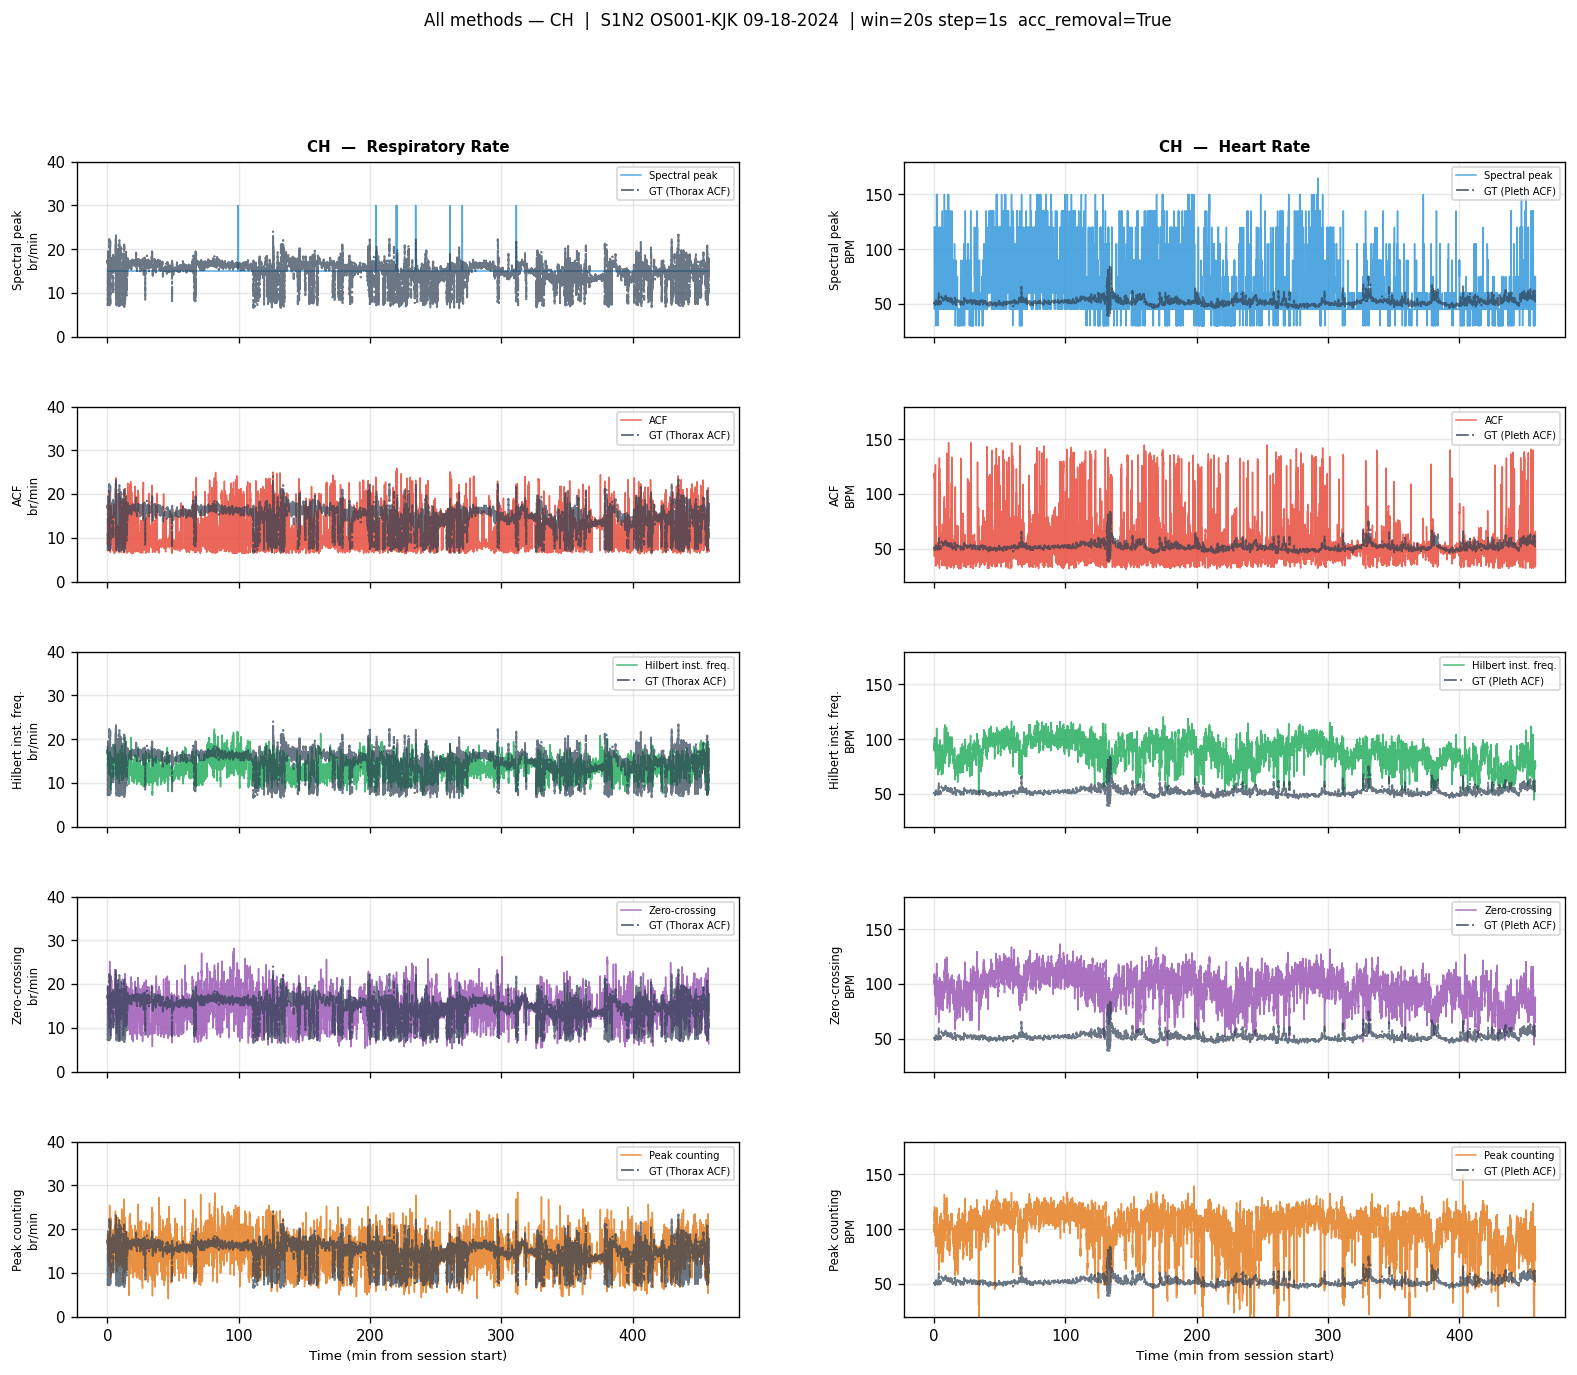

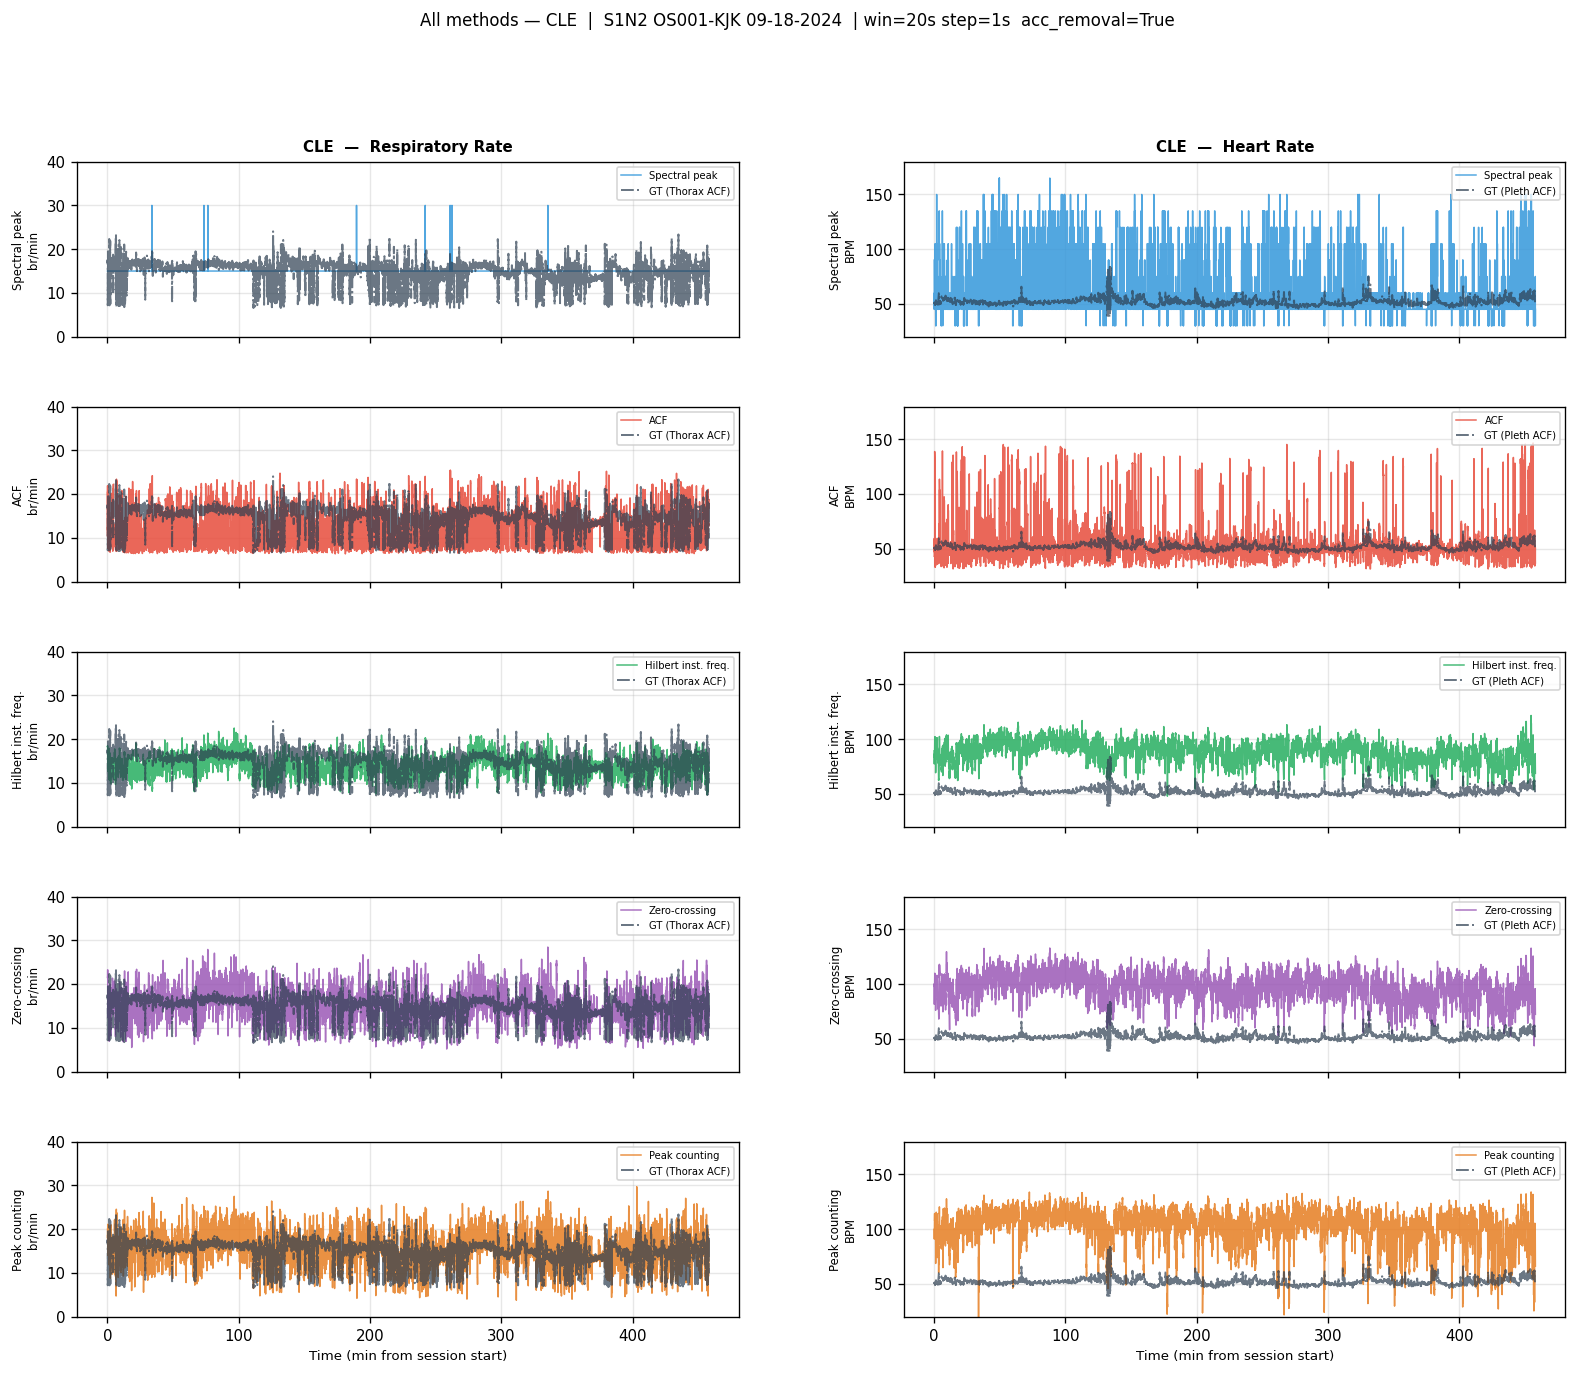

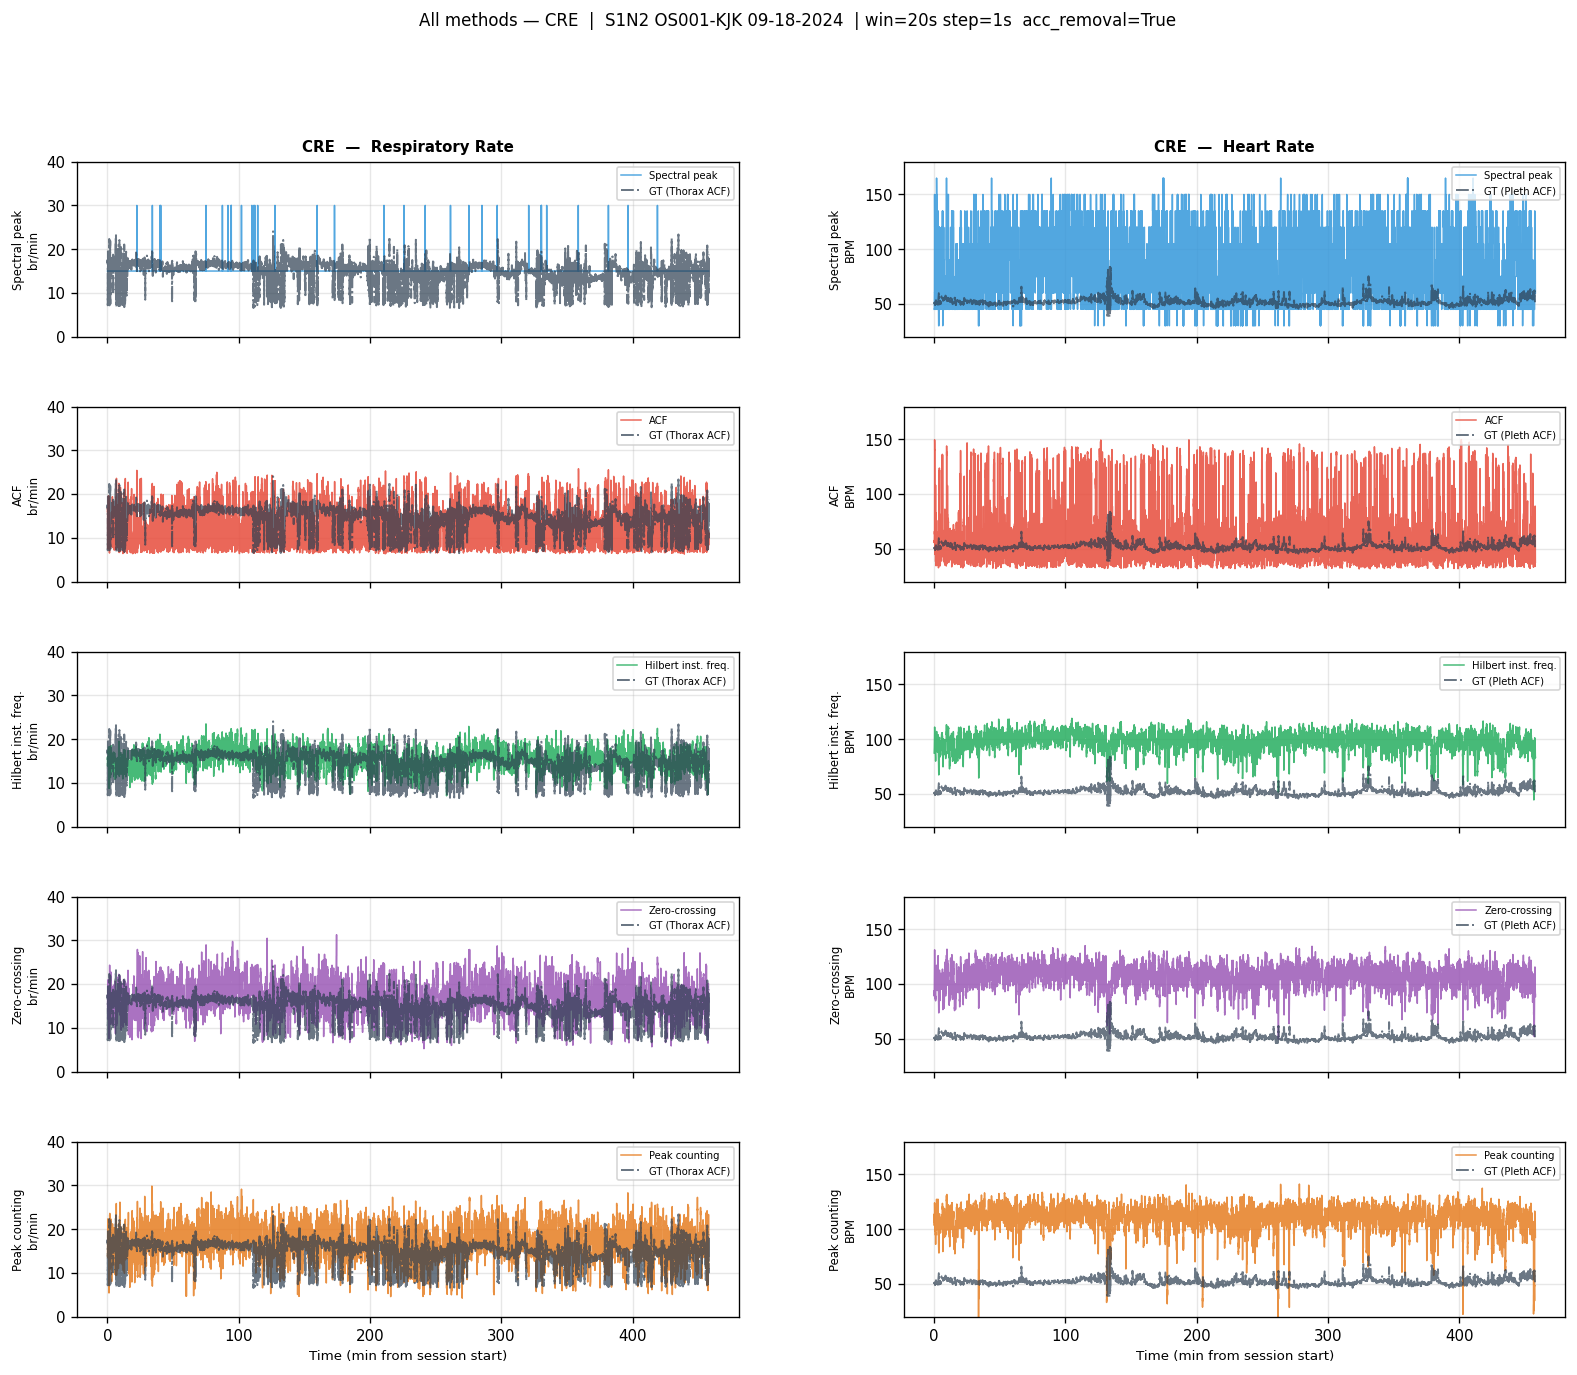

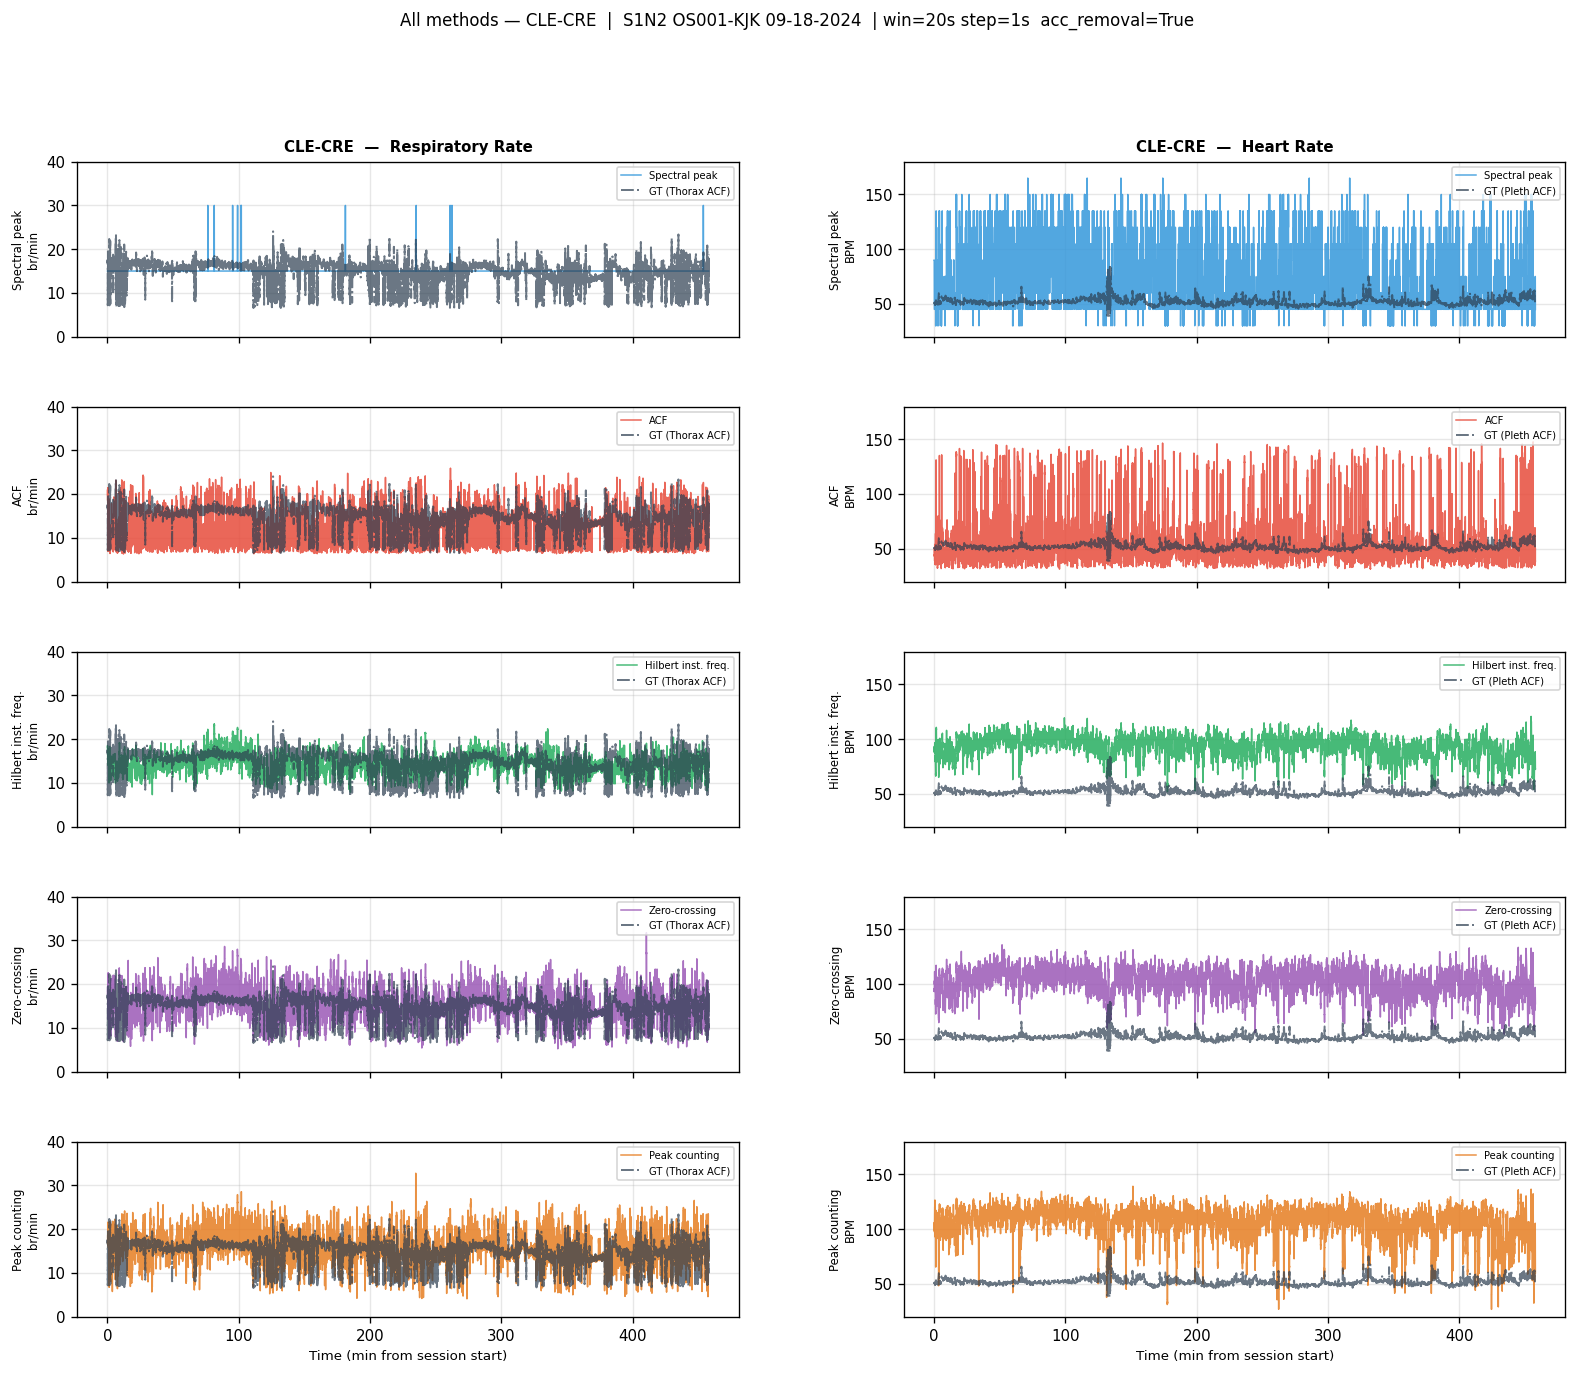

In [21]:
# ── Plot: one figure per cap channel, 2 columns (RR | HR), one row per method ─
METHOD_COLORS = {
    'spectral':  '#3498DB',
    'acf':       '#E74C3C',
    'hilbert':   '#27AE60',
    'zerocross': '#9B59B6',
    'peaks':     '#E67E22',
}
METHOD_LABELS = {
    'spectral':  'Spectral peak',
    'acf':       'ACF',
    'hilbert':   'Hilbert inst. freq.',
    'zerocross': 'Zero-crossing',
    'peaks':     'Peak counting',
}

for ch in CAP_CHANS:
    fig, axes = plt.subplots(len(METHOD_NAMES), 2,
                              figsize=(16, 2.5 * len(METHOD_NAMES)),
                              sharex='col', sharey='col',
                              gridspec_kw={'hspace': 0.4, 'wspace': 0.25})

    t_min = to_min(slide_t[ch]['resp'])

    for row, meth in enumerate(METHOD_NAMES):
        color = METHOD_COLORS[meth]

        # ── RR (col 0) ──
        ax = axes[row, 0]
        rr_hz = slide_results[ch]['resp'][meth]
        valid = ~np.isnan(rr_hz)
        ax.plot(t_min[valid], rr_hz[valid] * 60,
                lw=0.9, color=color, alpha=0.85, label=METHOD_LABELS[meth])
        gt_v = ~np.isnan(gt_rates_resp['acf'])
        ax.plot(gt_t_resp_min[gt_v], gt_rates_resp['acf'][gt_v] * 60,
                '-.', color=GT_COLOR, lw=1.2, alpha=0.7, label='GT (Thorax ACF)')
        ax.set_ylim(0, 40)
        ax.set_ylabel(f'{METHOD_LABELS[meth]}\nbr/min', fontsize=7)
        ax.legend(fontsize=6, loc='upper right')
        if row == 0:
            ax.set_title(f'{ch}  —  Respiratory Rate', fontsize=9, fontweight='bold')

        # ── HR (col 1) ──
        ax = axes[row, 1]
        hr_hz = slide_results[ch]['card'][meth]
        valid = ~np.isnan(hr_hz)
        ax.plot(to_min(slide_t[ch]['card'])[valid], hr_hz[valid] * 60,
                lw=0.9, color=color, alpha=0.85, label=METHOD_LABELS[meth])
        gt_v = ~np.isnan(gt_rates_card['acf'])
        ax.plot(gt_t_card_min[gt_v], gt_rates_card['acf'][gt_v] * 60,
                '-.', color=GT_COLOR, lw=1.2, alpha=0.7, label='GT (Pleth ACF)')
        ax.set_ylim(20, 180)
        ax.set_ylabel(f'{METHOD_LABELS[meth]}\nBPM', fontsize=7)
        ax.legend(fontsize=6, loc='upper right')
        if row == 0:
            ax.set_title(f'{ch}  —  Heart Rate', fontsize=9, fontweight='bold')

    axes[-1, 0].set_xlabel('Time (min from session start)', fontsize=8)
    axes[-1, 1].set_xlabel('Time (min from session start)', fontsize=8)
    fig.suptitle(
        f"All methods — {ch}  |  {m_nw['label']} {m_nw['subject']}-{m_nw['initials']} {m_nw['date']}  "
        f"| win={WIN_SEC:.0f}s step={STEP_SEC:.0f}s  acc_removal={ACC_REM_NW}",
        fontsize=10)
    plt.tight_layout()
    plt.show()

## 9 — Accuracy Metrics vs. Ground Truth

For each (channel × method) pair, compute MAE, RMSE, and Pearson r against the
PSG ground truth (GT ACF estimate on Thorax / Pleth). Only windows where both
cap and GT estimates are valid are included.

In [22]:
def interp_to_common(t_ref, vals_ref, t_query, vals_query):
    """
    Linearly interpolate vals_ref and vals_query onto the intersection of their
    valid time ranges. Returns (ref_interp, query_interp) at t_query times,
    excluding NaN entries in either series.
    """
    valid_ref   = ~np.isnan(vals_ref)
    valid_query = ~np.isnan(vals_query)
    if valid_ref.sum() < 2 or valid_query.sum() < 2:
        return np.array([]), np.array([])

    f_ref = interp1d(t_ref[valid_ref], vals_ref[valid_ref],
                     kind='linear', bounds_error=False, fill_value=np.nan)
    t_lo = max(t_ref[valid_ref][0],   t_query[valid_query][0])
    t_hi = min(t_ref[valid_ref][-1],  t_query[valid_query][-1])

    mask = valid_query & (t_query >= t_lo) & (t_query <= t_hi)
    if mask.sum() < 5:
        return np.array([]), np.array([])

    ref_at_query   = f_ref(t_query[mask])
    query_at_query = vals_query[mask]

    both_valid = ~np.isnan(ref_at_query) & ~np.isnan(query_at_query)
    return ref_at_query[both_valid], query_at_query[both_valid]


def accuracy_metrics(gt_t, gt_hz, cap_t, cap_hz):
    ref, pred = interp_to_common(gt_t, gt_hz, cap_t, cap_hz)
    if len(ref) < 5:
        return dict(n=0, mae=np.nan, rmse=np.nan, r=np.nan, bias=np.nan)
    err  = pred - ref
    mae  = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))
    r    = pearsonr(ref, pred)[0] if len(ref) > 2 else np.nan
    bias = np.mean(err)
    return dict(n=len(ref), mae=mae, rmse=rmse, r=r, bias=bias)


# ── Build metrics table ────────────────────────────────────────────────────────
rows = []
for ch in CAP_CHANS:
    for band, gt_t_arr, gt_rates_dict, unit, scale in [
        ('resp', gt_t_resp, gt_rates_resp, 'br/min', 60),
        ('card', gt_t_card, gt_rates_card, 'BPM',    60),
    ]:
        gt_hz = gt_rates_dict['acf']   # use ACF as reference GT rate
        cap_t = slide_t[ch][band]
        for meth in METHOD_NAMES:
            cap_hz = slide_results[ch][band][meth]
            met = accuracy_metrics(gt_t_arr, gt_hz, cap_t, cap_hz)
            rows.append({
                'Channel': ch, 'Band': band, 'Method': meth, 'Unit': unit,
                'n': met['n'],
                f'MAE ({unit})':  round(met['mae']  * scale, 2) if not np.isnan(met['mae'])  else np.nan,
                f'RMSE ({unit})': round(met['rmse'] * scale, 2) if not np.isnan(met['rmse']) else np.nan,
                'Pearson r':      round(met['r'],    3)         if not np.isnan(met['r'])    else np.nan,
                f'Bias ({unit})': round(met['bias'] * scale, 2) if not np.isnan(met['bias']) else np.nan,
            })

df_metrics = pd.DataFrame(rows)

print('=== Respiratory Rate (br/min) ===')
df_resp = df_metrics[df_metrics['Band'] == 'resp'].drop(columns=['Band','Unit'])
display(df_resp.sort_values(['Channel', 'MAE (br/min)']).reset_index(drop=True))

print('\n=== Heart Rate (BPM) ===')
df_card = df_metrics[df_metrics['Band'] == 'card'].drop(columns=['Band','Unit'])
display(df_card.sort_values(['Channel', 'MAE (BPM)']).reset_index(drop=True))

=== Respiratory Rate (br/min) ===


,Channel,Method,n,MAE (br/min),RMSE (br/min),Pearson r,Bias (br/min),MAE (BPM),RMSE (BPM),Bias (BPM)
0,CH,spectral,27461,1.67,2.36,0.003,0.13,NaN,NaN,NaN
1,CH,hilbert,27461,2.85,3.50,0.046,-1.66,NaN,NaN,NaN
2,CH,peaks,27383,3.03,4.06,0.056,0.02,NaN,NaN,NaN
3,CH,zerocross,27461,3.12,4.08,0.045,-0.71,NaN,NaN,NaN
4,CH,acf,26316,5.03,5.93,-0.041,-4.14,NaN,NaN,NaN
5,CLE,spectral,27461,1.67,2.35,0.007,0.12,NaN,NaN,NaN
6,CLE,hilbert,27461,2.55,3.23,0.142,-1.18,NaN,NaN,NaN
7,CLE,zerocross,27461,3.01,3.94,0.141,-0.10,NaN,NaN,NaN
8,CLE,peaks,27376,3.04,4.04,0.129,0.52,NaN,NaN,NaN
9,CLE,acf,26151,4.65,5.58,0.017,-3.70,NaN,NaN,NaN



=== Heart Rate (BPM) ===


,Channel,Method,n,MAE (br/min),RMSE (br/min),Pearson r,Bias (br/min),MAE (BPM),RMSE (BPM),Bias (BPM)
0,CH,acf,26543,NaN,NaN,-0.018,NaN,11.10,18.08,-0.84
1,CH,spectral,27461,NaN,NaN,-0.068,NaN,18.69,28.30,9.33
2,CH,hilbert,27461,NaN,NaN,-0.309,NaN,35.25,37.87,35.12
3,CH,zerocross,27461,NaN,NaN,-0.299,NaN,43.97,46.68,43.88
4,CH,peaks,27461,NaN,NaN,-0.308,NaN,47.39,50.99,46.53
5,CLE,acf,26863,NaN,NaN,0.019,NaN,8.01,14.41,-0.81
6,CLE,spectral,27461,NaN,NaN,0.006,NaN,15.42,24.38,7.03
7,CLE,hilbert,27461,NaN,NaN,-0.277,NaN,36.06,37.83,35.97
8,CLE,zerocross,27461,NaN,NaN,-0.265,NaN,44.37,46.43,44.31
9,CLE,peaks,27461,NaN,NaN,-0.342,NaN,49.53,52.16,49.06


## 10 — Method Comparison: Best Channel × Method per Task

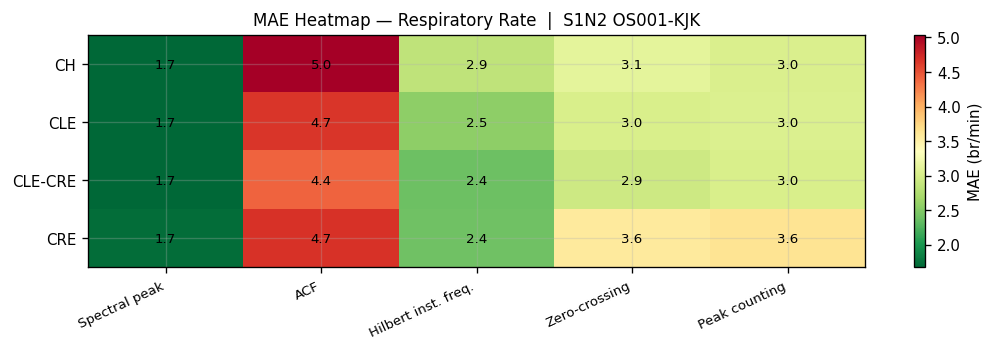

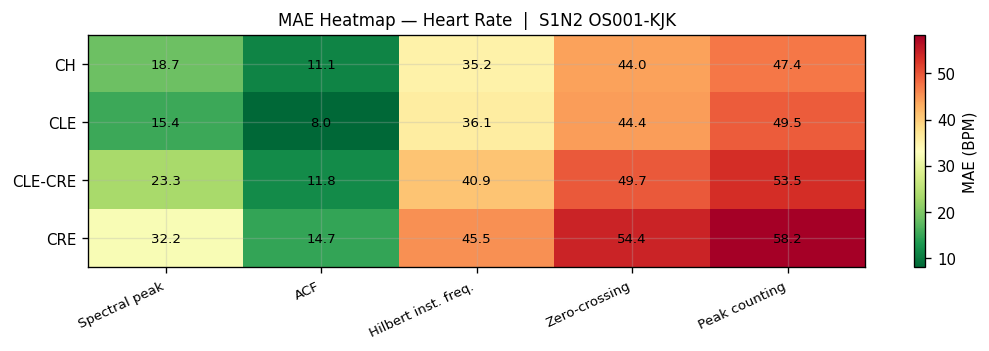

In [23]:
# Heatmap of MAE for each (channel, method) pair
for band, unit in [('resp', 'br/min'), ('card', 'BPM')]:
    pivot = (
        df_metrics[df_metrics['Band'] == band]
        .pivot(index='Channel', columns='Method', values=f'MAE ({unit})')
        [METHOD_NAMES]  # consistent column order
    )
    fig, ax = plt.subplots(figsize=(9, 3))
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r')
    ax.set_xticks(range(len(METHOD_NAMES)))
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHOD_NAMES], rotation=25, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    for i in range(len(pivot.index)):
        for j in range(len(METHOD_NAMES)):
            val = pivot.values[i, j]
            ax.text(j, i, f'{val:.1f}' if not np.isnan(val) else 'NaN',
                    ha='center', va='center', fontsize=8,
                    color='black' if not np.isnan(val) else 'gray')
    plt.colorbar(im, ax=ax, label=f'MAE ({unit})')
    title = 'Respiratory Rate' if band == 'resp' else 'Heart Rate'
    ax.set_title(f'MAE Heatmap — {title}  |  {m_nw["label"]} {m_nw["subject"]}-{m_nw["initials"]}',
                 fontsize=10)
    plt.tight_layout()
    plt.show()

Best RR: ('CH', 'spectral')   Best HR: ('CLE', 'acf')


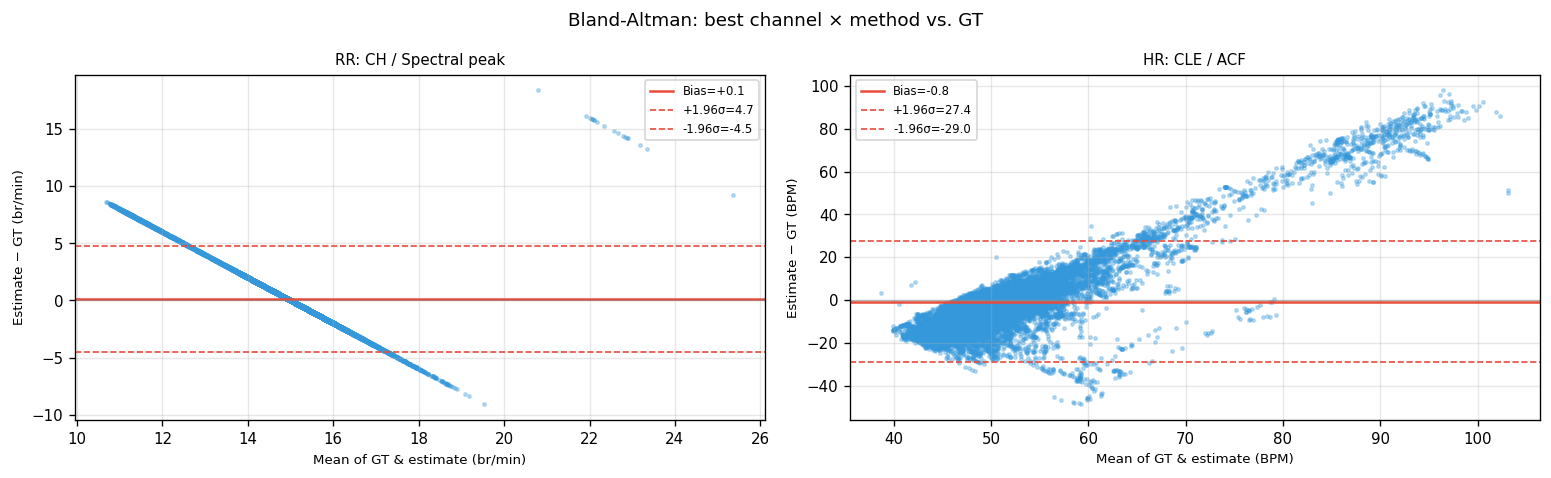

In [24]:
# Bland-Altman plot for the best-performing channel × method pair
def bland_altman(gt_t, gt_hz, cap_t, cap_hz, label, unit, ax):
    ref, pred = interp_to_common(gt_t, gt_hz, cap_t, cap_hz)
    if len(ref) < 5:
        ax.text(0.5, 0.5, 'insufficient data', transform=ax.transAxes, ha='center')
        return
    ref_pm  = ref  * 60
    pred_pm = pred * 60
    mean_  = (ref_pm + pred_pm) / 2.0
    diff_  = pred_pm - ref_pm
    bias   = np.mean(diff_)
    loa    = 1.96 * np.std(diff_)
    ax.scatter(mean_, diff_, s=4, alpha=0.3, color='#3498DB')
    ax.axhline(bias,       color='#E74C3C', lw=1.5, label=f'Bias={bias:+.1f}')
    ax.axhline(bias + loa, color='#E74C3C', lw=1.0, ls='--', label=f'+1.96σ={bias+loa:.1f}')
    ax.axhline(bias - loa, color='#E74C3C', lw=1.0, ls='--', label=f'-1.96σ={bias-loa:.1f}')
    ax.axhline(0,          color='gray',    lw=0.7, alpha=0.5)
    ax.set_xlabel(f'Mean of GT & estimate ({unit})', fontsize=8)
    ax.set_ylabel(f'Estimate − GT ({unit})', fontsize=8)
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7)


# Find best (channel, method) for RR and HR
def best_pair(band, unit):
    sub = df_metrics[df_metrics['Band'] == band].dropna(subset=[f'MAE ({unit})'])
    if sub.empty:
        return None
    row = sub.loc[sub[f'MAE ({unit})'].idxmin()]
    return row['Channel'], row['Method']

best_resp = best_pair('resp', 'br/min')
best_card = best_pair('card', 'BPM')
print(f'Best RR: {best_resp}   Best HR: {best_card}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
if best_resp:
    ch_r, meth_r = best_resp
    bland_altman(gt_t_resp, gt_rates_resp['acf'],
                 slide_t[ch_r]['resp'], slide_results[ch_r]['resp'][meth_r],
                 f'RR: {ch_r} / {METHOD_LABELS[meth_r]}', 'br/min', axes[0])
if best_card:
    ch_c, meth_c = best_card
    bland_altman(gt_t_card, gt_rates_card['acf'],
                 slide_t[ch_c]['card'], slide_results[ch_c]['card'][meth_c],
                 f'HR: {ch_c} / {METHOD_LABELS[meth_c]}', 'BPM', axes[1])
fig.suptitle('Bland-Altman: best channel × method vs. GT', fontsize=11)
plt.tight_layout()
plt.show()

## 11 — Ensemble Fusion (median across channels)

Combine all four cap channels by taking the **trimmed median** of their per-window
rate estimates. This can reduce the effect of a single noisy channel.

Fused RR (acf):  MAE=4.44 br/min  RMSE=5.24  r=0.001  bias=-3.94
Fused HR (acf):  MAE=7.15 BPM  RMSE=10.70  r=-0.041  bias=-1.95


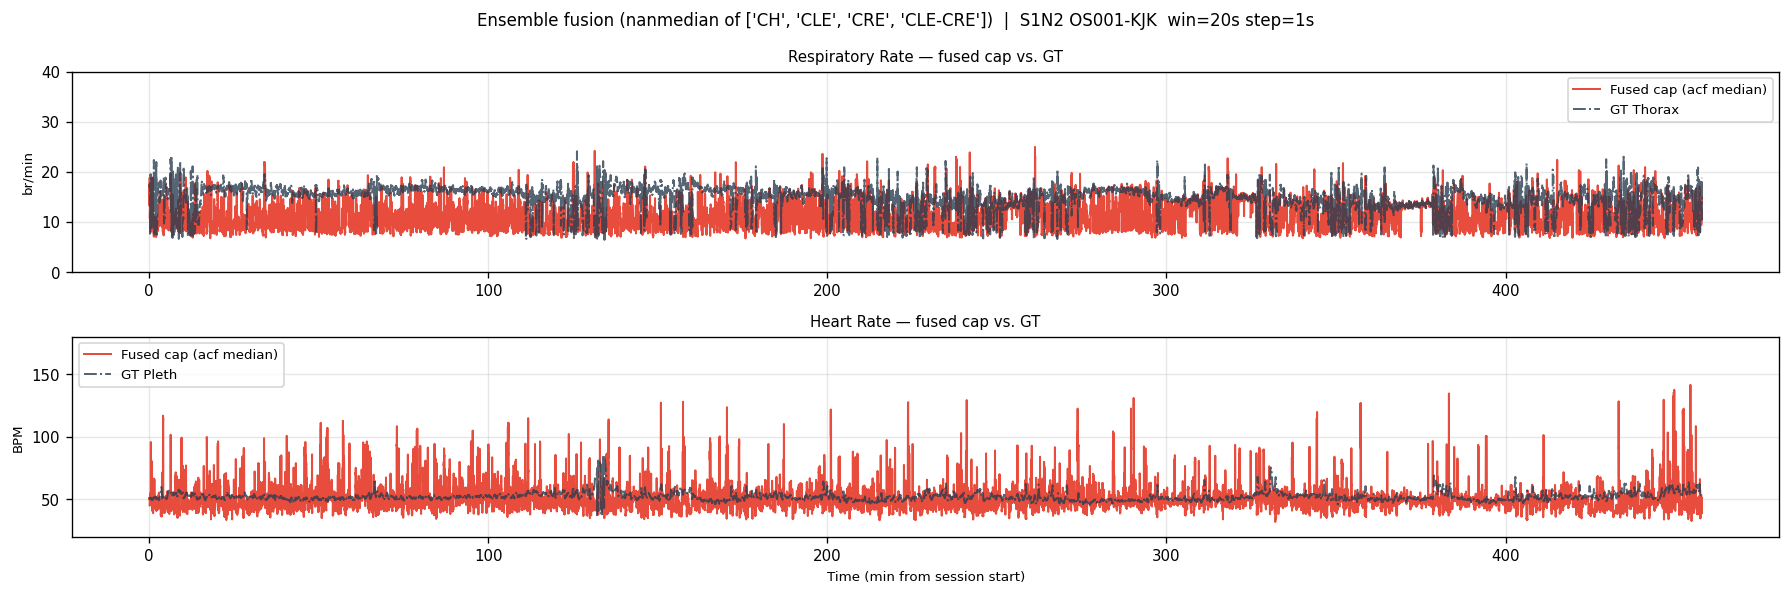

In [29]:
def fuse_channels(slide_results, slide_t, ch_list, band, meth, common_t):
    """
    Interpolate each channel's rate estimates onto common_t, then take
    nanmedian across channels at each time point.
    """
    interp_stack = []
    for ch in ch_list:
        t_ch  = slide_t[ch][band]
        hz_ch = slide_results[ch][band][meth]
        valid = ~np.isnan(hz_ch)
        if valid.sum() < 2:
            interp_stack.append(np.full(len(common_t), np.nan))
            continue
        fi = interp1d(t_ch[valid], hz_ch[valid],
                      kind='linear', bounds_error=False, fill_value=np.nan)
        interp_stack.append(fi(common_t))
    return np.nanmedian(np.vstack(interp_stack), axis=0)


FUSE_METHOD = 'acf'   # which single-channel method to fuse

# Use resp time axis as common grid
common_t_resp = slide_t['CH']['resp']
common_t_card = slide_t['CH']['card']

fused_rr = fuse_channels(slide_results, slide_t, CAP_CHANS, 'resp', FUSE_METHOD, common_t_resp)
fused_hr = fuse_channels(slide_results, slide_t, CAP_CHANS, 'card', FUSE_METHOD, common_t_card)

# Metrics for fused estimate
met_rr = accuracy_metrics(gt_t_resp, gt_rates_resp['acf'], common_t_resp, fused_rr)
met_hr = accuracy_metrics(gt_t_card, gt_rates_card['acf'], common_t_card, fused_hr)

print(f'Fused RR ({FUSE_METHOD}):  MAE={met_rr["mae"]*60:.2f} br/min  '
      f'RMSE={met_rr["rmse"]*60:.2f}  r={met_rr["r"]:.3f}  bias={met_rr["bias"]*60:+.2f}')
print(f'Fused HR ({FUSE_METHOD}):  MAE={met_hr["mae"]*60:.2f} BPM  '
      f'RMSE={met_hr["rmse"]*60:.2f}  r={met_hr["r"]:.3f}  bias={met_hr["bias"]*60:+.2f}')

fig, axes = plt.subplots(2, 1, figsize=(15, 5), sharex=False)
for ax, t_arr, fused, gt_t_arr, gt_rts, ylabel, ylim, gt_label in [
    (axes[0], common_t_resp, fused_rr, gt_t_resp, gt_rates_resp['acf'],
     'br/min', (0, 40),   'GT Thorax'),
    (axes[1], common_t_card, fused_hr, gt_t_card, gt_rates_card['acf'],
     'BPM',    (20, 180), 'GT Pleth'),
]:
    t_m = to_min(t_arr)
    valid = ~np.isnan(fused)
    ax.plot(t_m[valid], fused[valid] * 60,
            lw=1.2, color='#E74C3C', label=f'Fused cap ({FUSE_METHOD} median)')
    gt_valid = ~np.isnan(gt_rts)
    ax.plot(to_min(gt_t_arr)[gt_valid], gt_rts[gt_valid] * 60,
            '-.', color=GT_COLOR, lw=1.2, alpha=0.8, label=gt_label)
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.legend(fontsize=8)
axes[0].set_title('Respiratory Rate — fused cap vs. GT', fontsize=9)
axes[1].set_title('Heart Rate — fused cap vs. GT', fontsize=9)
axes[1].set_xlabel('Time (min from session start)', fontsize=8)
fig.suptitle(
    f"Ensemble fusion (nanmedian of {CAP_CHANS})  |  "
    f"{m_nw['label']} {m_nw['subject']}-{m_nw['initials']}  "
    f"win={WIN_SEC:.0f}s step={STEP_SEC:.0f}s",
    fontsize=10)
plt.tight_layout()
plt.show()

## 12 — 1-Minute Peak Inspection

Self-contained: set `INSP_SUBJECT`, `INSP_NIGHT`, and `INSP_START_HR` then run.

**Each row** = one cap channel (+ GT row at the bottom).
**Left column** = respiratory band | **right column** = cardiac band.

- Grey trace = raw signal (z-scored)
- Coloured trace = bandpass-filtered (acc-regression applied)
- Coloured ▽ = cap detected peaks
- Dark △ = GT peaks (Thorax resp | Pleth card)
- Faint vertical lines = GT peak times projected onto cap panels

C:\Users\adity\AppData\Local\Temp\ipykernel_1308\1274123575.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


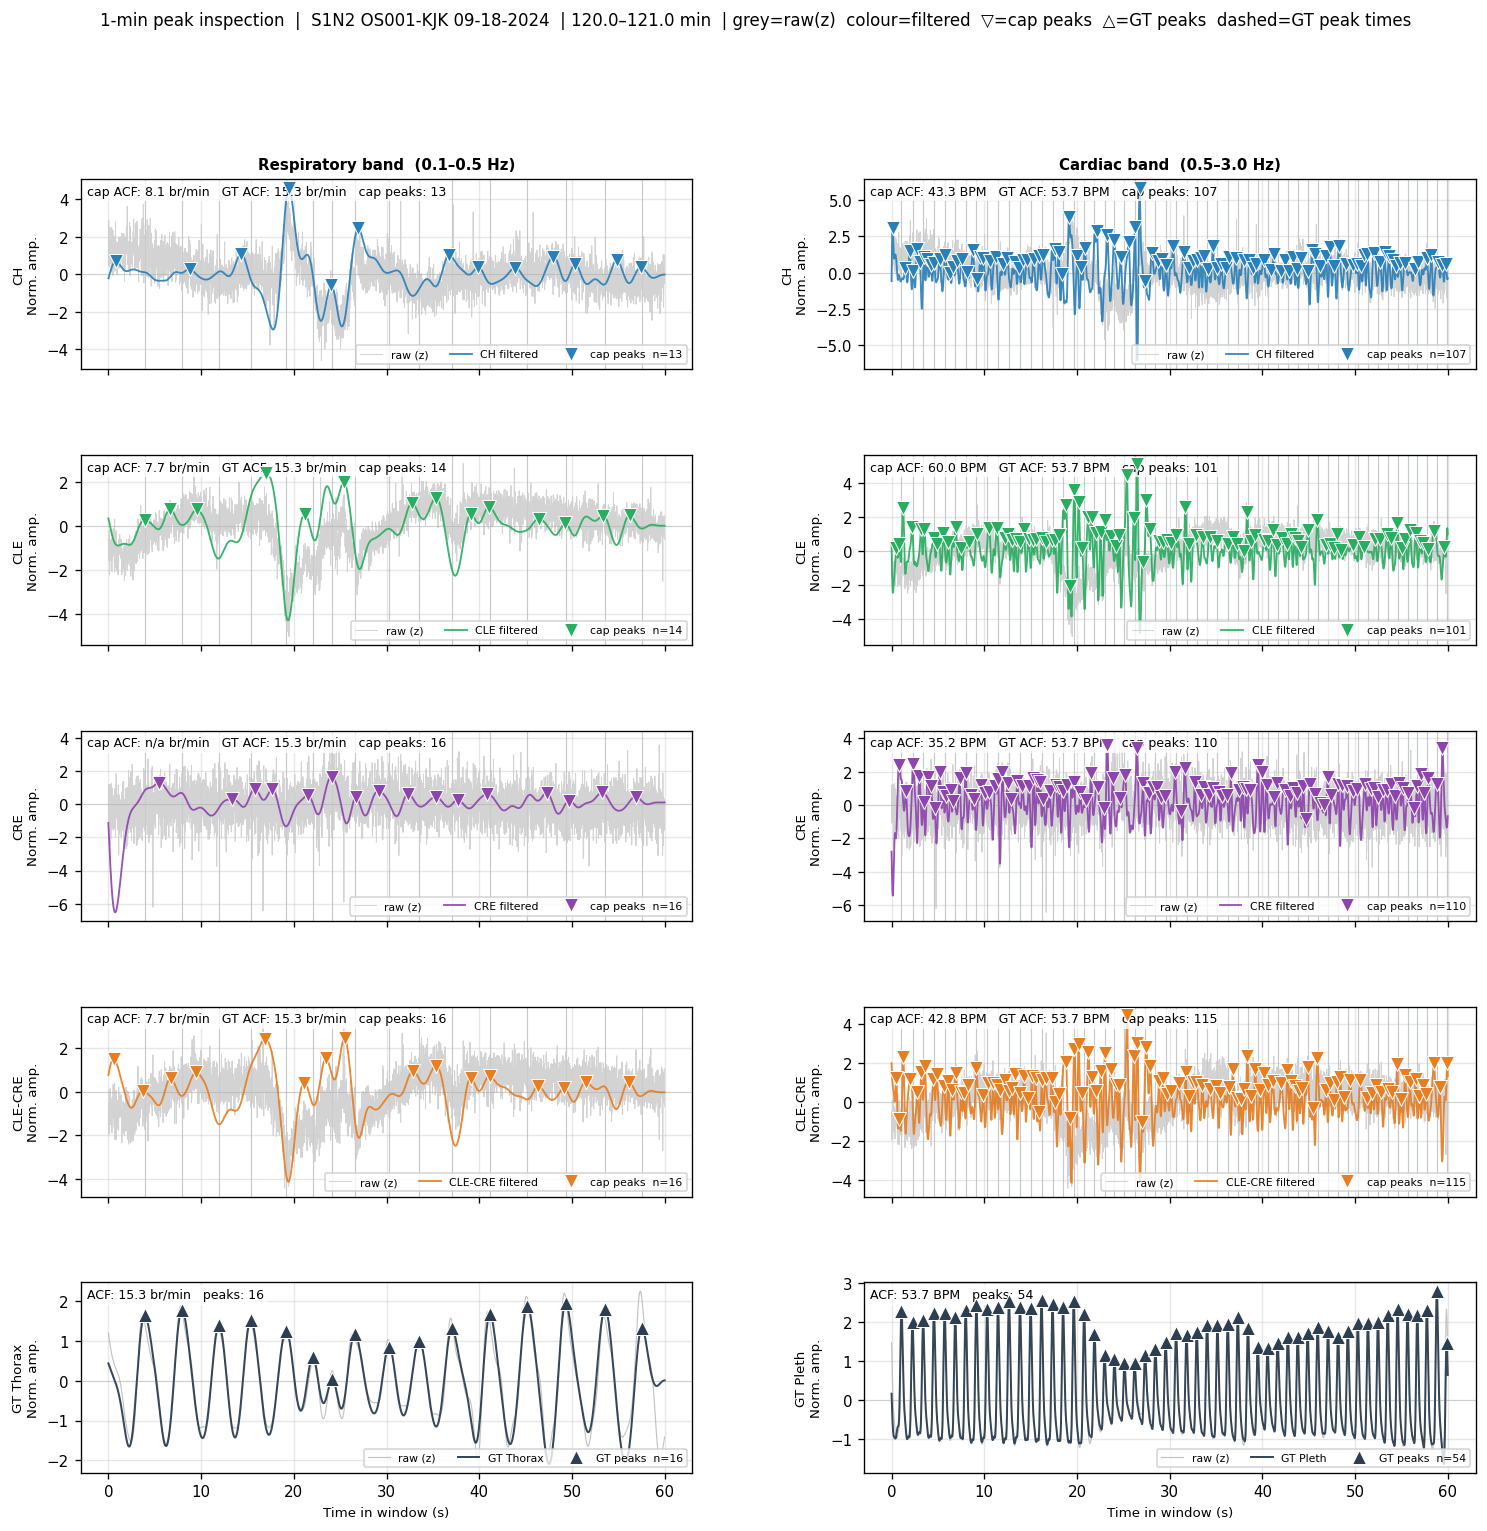

In [30]:
# ── Parameters ─────────────────────────────────────────────────────────────────────────────
INSP_SUBJECT  = 'OS001'
INSP_NIGHT    = 2
INSP_START_HR = 2.0        # start of the 1-minute window (hours)
INSP_ACC_REM  = True       # apply accelerometer motion removal
# ──────────────────────────────────────────────────────────────────────────────

from scipy.signal import find_peaks as _fp_insp

INSP_WIN_HR = 1 / 60       # fixed: 1 minute

INSP_SID = next(m['idx'] for m in SESSION_META
                if m['subject'] == INSP_SUBJECT and m['night'] == INSP_NIGHT)
s_insp   = sessions[INSP_SID]
m_insp   = s_insp['meta']
win_insp = prep_window(s_insp, INSP_START_HR, INSP_WIN_HR,
                        apply_acc_removal=INSP_ACC_REM)

t_insp = win_insp['t_s']
_idx   = win_insp['idx']
_cap   = s_insp['cap']
_psg   = s_insp['psg']

def _zsc(x):
    return (x - x.mean()) / (x.std() + 1e-12)

# Raw z-scored signals for the window
raw_insp = {
    'CH':     _zsc(_cap['CH'][_idx].astype(float)),
    'CLE':    _zsc(_cap['CLE'][_idx].astype(float)),
    'CRE':    _zsc(_cap['CRE'][_idx].astype(float)),
    'Thorax': _zsc(_psg['Thorax'][_idx].astype(float)),
    'Pleth':  _zsc(_psg['Pleth'][_idx].astype(float)),
}
raw_insp['CLE-CRE'] = _zsc(
    _cap['CLE'][_idx].astype(float) - _cap['CRE'][_idx].astype(float)
)

def _detect_insp(sig, f_lo, f_hi, prom=0.4):
    dist = max(1, int(0.9 * FS / f_hi))
    pks, _ = _fp_insp(sig, distance=dist, prominence=prom * np.std(sig))
    return pks

# GT peaks on bandpassed GT signals
gt_resp_bp_insp  = win_insp['gt_resp']
gt_card_bp_insp  = win_insp['gt_card']
gt_resp_pks_insp = _detect_insp(gt_resp_bp_insp, RESP_LO, RESP_HI)
gt_card_pks_insp = _detect_insp(gt_card_bp_insp, CARD_LO, CARD_HI)

# ── Figure ───────────────────────────────────────────────────────────────────────────────
ROWS_INSP = CAP_CHANS + ['GT']
fig_i, axes_i = plt.subplots(
    len(ROWS_INSP), 2,
    figsize=(15, 2.8 * len(ROWS_INSP)),
    sharex=True,
    gridspec_kw={'hspace': 0.45, 'wspace': 0.28}
)

BAND_SPECS = [
    ('resp', RESP_LO, RESP_HI, gt_resp_bp_insp, gt_resp_pks_insp, 'Thorax', 'GT Thorax', 'br/min'),
    ('card', CARD_LO, CARD_HI, gt_card_bp_insp, gt_card_pks_insp, 'Pleth',  'GT Pleth',  'BPM'),
]

for ri, row_id in enumerate(ROWS_INSP):
    is_gt = (row_id == 'GT')
    color = GT_COLOR if is_gt else CAP_COLORS[row_id]

    for ci, (band, f_lo, f_hi, gt_bp, gt_pks, raw_key, gt_lbl, unit) in enumerate(BAND_SPECS):
        ax = axes_i[ri, ci]
        gt_filt_z = _zsc(gt_bp)

        if is_gt:
            ax.plot(t_insp, raw_insp[raw_key],
                    color='#AAAAAA', lw=0.7, alpha=0.70, label='raw (z)')
            ax.plot(t_insp, gt_filt_z,
                    color=GT_COLOR, lw=1.2, alpha=0.95, label=gt_lbl)
            ax.plot(t_insp[gt_pks], gt_filt_z[gt_pks], '^',
                    color=GT_COLOR, ms=8, zorder=5,
                    markeredgecolor='white', markeredgewidth=0.6,
                    label=f'GT peaks  n={len(gt_pks)}')
            r_gt = rate_acf(gt_bp, f_lo, f_hi)
            r_str = f'{r_gt*60:.1f} {unit}' if not np.isnan(r_gt) else 'n/a'
            ax.text(0.01, 0.97, f'ACF: {r_str}   peaks: {len(gt_pks)}',
                    transform=ax.transAxes, va='top', fontsize=7.5,
                    bbox=dict(facecolor='white', alpha=0.78, pad=2, edgecolor='none'))
            ax.set_ylabel(f'{gt_lbl}\nNorm. amp.', fontsize=8)

        else:
            cap_filt   = win_insp['sigs'][row_id][band]
            cap_filt_z = _zsc(cap_filt)
            cap_pks    = _detect_insp(cap_filt, f_lo, f_hi)

            ax.plot(t_insp, raw_insp[row_id],
                    color='#CCCCCC', lw=0.6, alpha=0.85, label='raw (z)')
            ax.plot(t_insp, cap_filt_z,
                    color=color, lw=1.1, alpha=0.92, label=f'{row_id} filtered')
            ax.plot(t_insp[cap_pks], cap_filt_z[cap_pks], 'v',
                    color=color, ms=8, zorder=5,
                    markeredgecolor='white', markeredgewidth=0.6,
                    label=f'cap peaks  n={len(cap_pks)}')
            # GT peak times as faint vertical lines
            for pk in gt_pks:
                ax.axvline(t_insp[pk], color=GT_COLOR, lw=0.7, alpha=0.28, zorder=1)

            r_cap = rate_acf(cap_filt, f_lo, f_hi)
            r_gt  = rate_acf(gt_bp,    f_lo, f_hi)
            c_s = f'{r_cap*60:.1f}' if not np.isnan(r_cap) else 'n/a'
            g_s = f'{r_gt*60:.1f}'  if not np.isnan(r_gt)  else 'n/a'
            ax.text(0.01, 0.97,
                    f'cap ACF: {c_s} {unit}   GT ACF: {g_s} {unit}   cap peaks: {len(cap_pks)}',
                    transform=ax.transAxes, va='top', fontsize=7.5,
                    bbox=dict(facecolor='white', alpha=0.78, pad=2, edgecolor='none'))
            ax.set_ylabel(f'{row_id}\nNorm. amp.', fontsize=8)

        ax.axhline(0, color='gray', lw=0.4, alpha=0.35)
        ax.legend(fontsize=6.5, loc='lower right', ncol=3)
        if ri == 0:
            band_lbl = 'Respiratory' if ci == 0 else 'Cardiac'
            ax.set_title(f'{band_lbl} band  ({f_lo}\u2013{f_hi} Hz)',
                         fontsize=9, fontweight='bold')

for ci in range(2):
    axes_i[-1, ci].set_xlabel('Time in window (s)', fontsize=8)

t0m = INSP_START_HR * 60
t1m = (INSP_START_HR + INSP_WIN_HR) * 60
fig_i.suptitle(
    f"1-min peak inspection  |  {m_insp['label']} "
    f"{m_insp['subject']}-{m_insp['initials']} {m_insp['date']}  "
    f"| {t0m:.1f}\u2013{t1m:.1f} min  "
    "| grey=raw(z)  colour=filtered  "
    "\u25bd=cap peaks  \u25b3=GT peaks  dashed=GT peak times",
    fontsize=10
)
plt.tight_layout()
plt.show()


## 12 — Short-Window Zoom: Fused Estimate vs. GT

GT resp peaks in window: 15   GT card peaks in window: 51


C:\Users\adity\AppData\Local\Temp\ipykernel_1308\1978290168.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


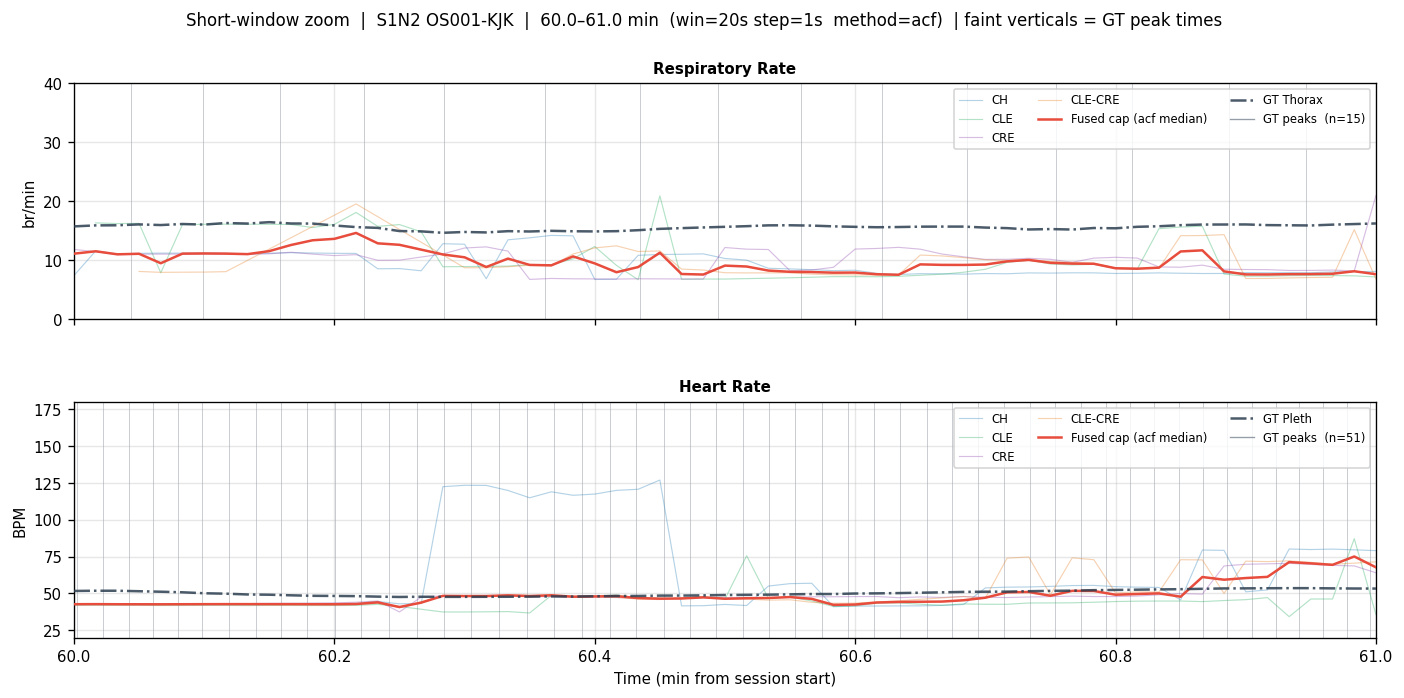

In [32]:
# ── Parameters — change to zoom into any segment of the night ─────────────────
ZOOM_START_MIN = 60.0   # start of zoom window (minutes from session start)
ZOOM_DUR_MIN   = 1.0   # duration to display (minutes)
# ──────────────────────────────────────────────────────────────────────────────

zoom_end_min = ZOOM_START_MIN + ZOOM_DUR_MIN

# ── Detect GT peaks within the zoom window ────────────────────────────────────
t_nw_s       = (t_nw - t_nw[0]) * 3600.0          # seconds from session start
t_nw_min_abs = to_min(t_nw_s)                      # absolute minutes

zoom_fs_mask = (t_nw_min_abs >= ZOOM_START_MIN) & (t_nw_min_abs <= zoom_end_min)
zoom_fs_idx  = np.where(zoom_fs_mask)[0]

gt_resp_zoom = gt_thorax_bp[zoom_fs_mask]
gt_card_zoom = gt_pleth_bp[zoom_fs_mask]

def _detect_zoom(sig, f_lo, f_hi, prom=0.4):
    dist = max(1, int(0.9 * FS / f_hi))
    pks, _ = find_peaks(sig, distance=dist, prominence=prom * np.std(sig))
    return pks

gt_resp_pks_zoom = _detect_zoom(gt_resp_zoom, RESP_LO, RESP_HI)
gt_card_pks_zoom = _detect_zoom(gt_card_zoom, CARD_LO, CARD_HI)

gt_resp_pks_min = t_nw_min_abs[zoom_fs_idx[gt_resp_pks_zoom]]
gt_card_pks_min = t_nw_min_abs[zoom_fs_idx[gt_card_pks_zoom]]
print(f'GT resp peaks in window: {len(gt_resp_pks_min)}   '
      f'GT card peaks in window: {len(gt_card_pks_min)}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                          gridspec_kw={'hspace': 0.35})

for ax, t_arr, fused, gt_t_arr, gt_rts, ylabel, ylim, gt_label, title, gt_pks_min in [
    (axes[0], common_t_resp, fused_rr, gt_t_resp, gt_rates_resp['acf'],
     'br/min', (0, 40),   'GT Thorax', 'Respiratory Rate', gt_resp_pks_min),
    (axes[1], common_t_card, fused_hr, gt_t_card, gt_rates_card['acf'],
     'BPM',   (20, 180), 'GT Pleth',  'Heart Rate',        gt_card_pks_min),
]:
    t_min_arr  = to_min(t_arr)
    gt_min_arr = to_min(gt_t_arr)

    zoom_mask_cap = (t_min_arr  >= ZOOM_START_MIN) & (t_min_arr  <= zoom_end_min)
    zoom_mask_gt  = (gt_min_arr >= ZOOM_START_MIN) & (gt_min_arr <= zoom_end_min)

    t_cap_z  = t_min_arr[zoom_mask_cap]
    fused_z  = fused[zoom_mask_cap]
    t_gt_z   = gt_min_arr[zoom_mask_gt]
    gt_rts_z = gt_rts[zoom_mask_gt]

    valid_cap = ~np.isnan(fused_z)
    valid_gt  = ~np.isnan(gt_rts_z)

    # GT peak times as faint vertical lines (drawn first, behind everything)
    for pk_min in gt_pks_min:
        ax.axvline(pk_min, color=GT_COLOR, lw=0.6, alpha=0.25, zorder=1)

    # Per-channel traces (thin, semi-transparent)
    band = 'resp' if ylabel == 'br/min' else 'card'
    for ch in CAP_CHANS:
        t_ch  = to_min(slide_t[ch][band])
        hz_ch = slide_results[ch][band][FUSE_METHOD]
        mask_ch = (t_ch >= ZOOM_START_MIN) & (t_ch <= zoom_end_min) & ~np.isnan(hz_ch)
        ax.plot(t_ch[mask_ch], hz_ch[mask_ch] * 60,
                lw=0.7, alpha=0.35, color=CAP_COLORS[ch], label=ch)

    ax.plot(t_cap_z[valid_cap], fused_z[valid_cap] * 60,
            lw=1.5, color='#E74C3C', label=f'Fused cap ({FUSE_METHOD} median)', zorder=3)
    ax.plot(t_gt_z[valid_gt], gt_rts_z[valid_gt] * 60,
            '-.', color=GT_COLOR, lw=1.5, alpha=0.85, label=gt_label, zorder=3)

    # Invisible proxy for the GT peak lines in legend
    ax.axvline(np.nan, color=GT_COLOR, lw=0.8, alpha=0.5,
               label=f'GT peaks  (n={len(gt_pks_min)})')

    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right', ncol=3)
    ax.set_xlim(ZOOM_START_MIN, zoom_end_min)

axes[-1].set_xlabel('Time (min from session start)', fontsize=9)
fig.suptitle(
    f"Short-window zoom  |  {m_nw['label']} {m_nw['subject']}-{m_nw['initials']}  "
    f"|  {ZOOM_START_MIN:.1f}\u2013{zoom_end_min:.1f} min  "
    f"(win={WIN_SEC:.0f}s step={STEP_SEC:.0f}s  method={FUSE_METHOD})  "
    "| faint verticals = GT peak times",
    fontsize=10)
plt.tight_layout()
plt.show()


C:\Users\adity\AppData\Local\Temp\ipykernel_1308\93724713.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


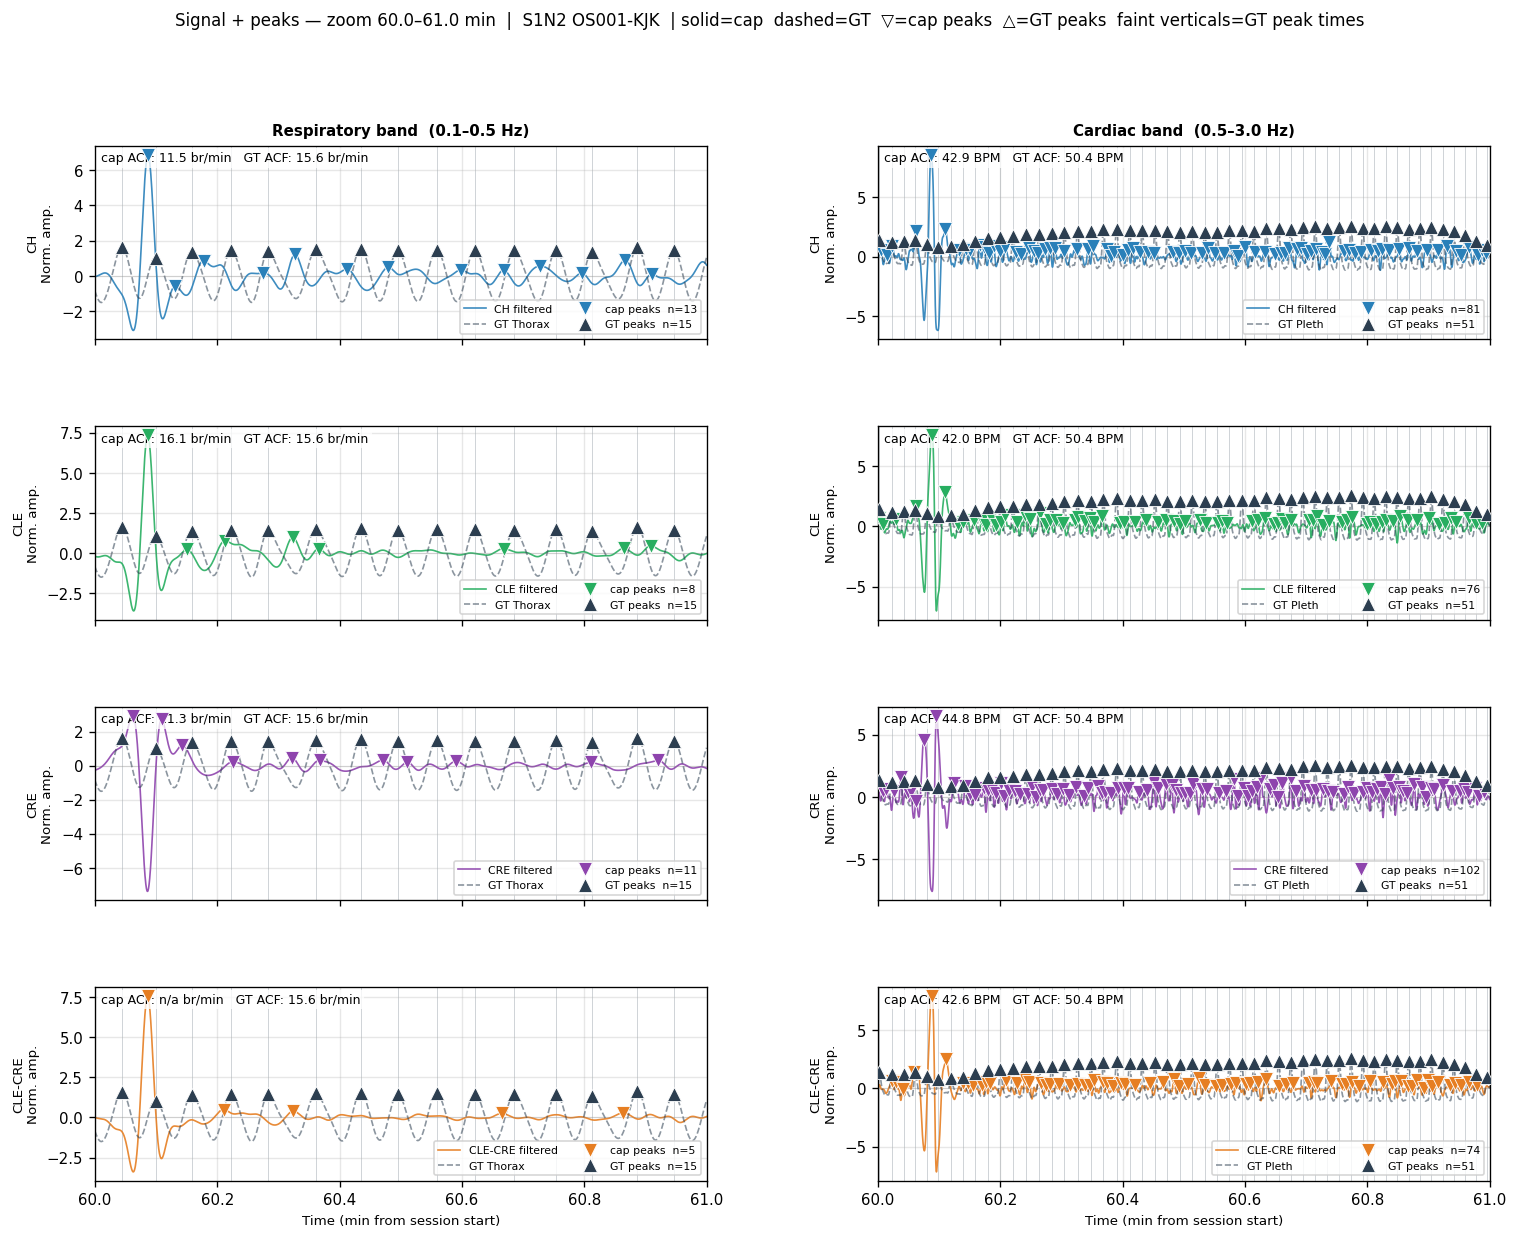

In [33]:
# ── Signal + peak overlay for the zoom window ─────────────────────────────────
# Uses ZOOM_START_MIN / ZOOM_DUR_MIN and gt_*_pks_min computed in the cell above.
# Extracts the raw samples directly from the full-session preprocessed signals.

# Sample indices for the zoom window
zoom_s0 = int(ZOOM_START_MIN * 60 * FS)   # first sample (approx)
zoom_s1 = int(zoom_end_min   * 60 * FS)
zoom_s0 = max(0, zoom_s0)
zoom_s1 = min(len(gt_thorax_bp), zoom_s1)

t_sig_min = t_nw_min_abs[zoom_s0:zoom_s1]   # absolute minutes for x-axis

def _zsc_sig(x):
    return (x - x.mean()) / (x.std() + 1e-12)

def _detect_sig(sig, f_lo, f_hi, prom=0.4):
    dist = max(1, int(0.9 * FS / f_hi))
    pks, _ = find_peaks(sig, distance=dist, prominence=prom * np.std(sig))
    return pks

fig2, axes2 = plt.subplots(len(CAP_CHANS), 2,
                             figsize=(15, 2.8 * len(CAP_CHANS)),
                             sharex=True,
                             gridspec_kw={'hspace': 0.45, 'wspace': 0.28})

for row, ch in enumerate(CAP_CHANS):
    color = CAP_COLORS[ch]

    for col, (band, f_lo, f_hi, gt_bp, gt_pks_min, gt_lbl, unit) in enumerate([
        ('resp', RESP_LO, RESP_HI, gt_thorax_bp, gt_resp_pks_min, 'GT Thorax', 'br/min'),
        ('card', CARD_LO, CARD_HI, gt_pleth_bp,  gt_card_pks_min, 'GT Pleth',  'BPM'),
    ]):
        ax = axes2[row, col]

        # Extract and z-score signals for the zoom window
        cap_sig_zoom = full_sigs[ch][band][zoom_s0:zoom_s1]
        gt_sig_zoom  = gt_bp[zoom_s0:zoom_s1]
        cap_z = _zsc_sig(cap_sig_zoom)
        gt_z  = _zsc_sig(gt_sig_zoom)

        # Detect peaks on the zoom-window segment
        cap_pks = _detect_sig(cap_sig_zoom, f_lo, f_hi)
        gt_pks  = _detect_sig(gt_sig_zoom,  f_lo, f_hi)

        # Faint GT peak vertical lines (behind everything)
        for pk in gt_pks:
            ax.axvline(t_sig_min[pk], color=GT_COLOR, lw=0.6, alpha=0.22, zorder=1)

        # Signals
        ax.plot(t_sig_min, cap_z, color=color, lw=1.0, alpha=0.90,
                label=f'{ch} filtered', zorder=2)
        ax.plot(t_sig_min, gt_z,  color=GT_COLOR, lw=1.0, alpha=0.55,
                ls='--', label=gt_lbl, zorder=2)

        # Cap peaks
        ax.plot(t_sig_min[cap_pks], cap_z[cap_pks], 'v',
                color=color, ms=8, zorder=5,
                markeredgecolor='white', markeredgewidth=0.5,
                label=f'cap peaks  n={len(cap_pks)}')

        # GT peaks (triangles on the GT trace)
        ax.plot(t_sig_min[gt_pks], gt_z[gt_pks], '^',
                color=GT_COLOR, ms=8, zorder=5,
                markeredgecolor='white', markeredgewidth=0.5,
                label=f'GT peaks  n={len(gt_pks)}')

        # Rate annotation
        r_cap = rate_acf(cap_sig_zoom, f_lo, f_hi)
        r_gt  = rate_acf(gt_sig_zoom,  f_lo, f_hi)
        c_s = f'{r_cap*60:.1f}' if not np.isnan(r_cap) else 'n/a'
        g_s = f'{r_gt*60:.1f}'  if not np.isnan(r_gt)  else 'n/a'
        ax.text(0.01, 0.97,
                f'cap ACF: {c_s} {unit}   GT ACF: {g_s} {unit}',
                transform=ax.transAxes, va='top', fontsize=7.5,
                bbox=dict(facecolor='white', alpha=0.78, pad=2, edgecolor='none'))

        ax.axhline(0, color='gray', lw=0.4, alpha=0.35)
        ax.set_ylabel(f'{ch}\nNorm. amp.', fontsize=8)
        ax.legend(fontsize=6.5, loc='lower right', ncol=2)
        ax.set_xlim(ZOOM_START_MIN, zoom_end_min)

        if row == 0:
            band_lbl = 'Respiratory' if col == 0 else 'Cardiac'
            ax.set_title(f'{band_lbl} band  ({f_lo}\u2013{f_hi} Hz)',
                         fontsize=9, fontweight='bold')

for col in range(2):
    axes2[-1, col].set_xlabel('Time (min from session start)', fontsize=8)

fig2.suptitle(
    f"Signal + peaks — zoom {ZOOM_START_MIN:.1f}\u2013{zoom_end_min:.1f} min  "
    f"|  {m_nw['label']} {m_nw['subject']}-{m_nw['initials']}  "
    "| solid=cap  dashed=GT  \u25bd=cap peaks  \u25b3=GT peaks  "
    "faint verticals=GT peak times",
    fontsize=10)
plt.tight_layout()
plt.show()
